#### Results 5.2 — Error-conditioned pedagogical signals in the constructed preference dataset (RQ 1)

Figures and numbers for Section 5.2 (methodology: Sections 4.4.2 and 4.4.3). Everything is read back from the tables that stage 1 (preference dataset construction) already saved: no generation, no classifier call, no new scoring. Section 6 only re-applies the saved PPMI table to the saved posteriors.

Inputs, all from stage 1:
- the contingency table (first-turn move × error-type counts, 693 training dialogues) and the PPMI table PPMI(m, e), the utility u(m, e)
- the candidate table (48,839 unique candidates: classifier posterior, score, model) and the pair table (24,298 preference pairs built from the candidates)

Outputs: the figures (PDF + PNG), one CSV per figure with the numbers behind it, the LaTeX drafts (Section 5.2, Chapter 6 paragraphs, two appendix sections) with their tables, and a compiled preview PDF (Section 12).

Figures in the current draft (file name → LaTeX label → number in the preview; the numbers shift once the text is merged into the results chapter):
- `fig_5_6_associations` → `fig:associations` → Figure 5.7 (Section 5.2.1)
- `fig_5_7_context_ranking` → `fig:context_ranking` → Figure 5.8, with Table 5.2 = `table_example_pairs.tex` (Section 5.2.2)
- `fig_5_8_posterior_shift` → `fig:posterior_shift` → Figure A.2 (Appendix B, summarized in Section 5.2.2; cited in the Chapter 6 draft)
- `fig_5_11_margin_by_pair` → `fig:margin_by_pair` → Figure 5.9, with the optional `table_margin_by_pair.tex` (Section 5.2.2)
- `fig_A_contexts` → `fig:app_contexts` → Figure A.1, one context per error type, 3 × 3 blocks (Appendix A)
- `fig_5_12_model_composition` → `fig:model_composition` → Figure 5.10 (Section 5.2.2, built in Section 9a; discussed in the Chapter 6 draft)
- `table_candidate_pool.tex` → `tab:candidate_pool` → Table A.1, move distribution of the candidate pool per error type (Appendix B, built in Section 8; cited in 5.2.2 and in the Chapter 6 draft)

Kept but not in the current draft: `fig_alt_associated_move` and `fig_5_9_associated_move_share` (Sections 4–5; the simplified 5.9/5.10 of an earlier draft), `fig_5_10_utility_swap` (Section 6; its numbers are quoted in the Chapter 6 draft), the alternative views of Sections 10–11 (`fig_alt_*`), and the seven one-context figures `fig_A_<k>_<error>` (Section 7b, only with `SAVE_SINGLE_CONTEXT_FIGURES = True`). The file numbers `fig_5_6 … fig_5_11` are historical and are kept so that the tex files need no change.

Run order: top to bottom (Section 12 needs the figures of all earlier sections). Nothing is written to the thesis folder.


#### 0. Setup


In [2]:
import ast
import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm


# Repository root = the folder that holds the stage folders. Walk up from the notebook's cwd (figure_notebooks/).
def find_repository_root():
    for folder in [Path.cwd(), *Path.cwd().parents]:
        if (folder / "1__tutor_response_generation__preference_dataset_construction").is_dir():
            return folder
    raise FileNotFoundError("open this notebook inside ____Final_Thesis_Repository")


ROOT = find_repository_root()
STAGE1 = ROOT / "1__tutor_response_generation__preference_dataset_construction"
PMI_DIR = STAGE1 / "data_pmi_table"   # contingency_table.csv, ppmi_table.csv
PAIR_DIR = STAGE1 / "data_preference_train_only" / "bridge_2tage__with_reference_solution_more_models"
CANDIDATES_FILE = PAIR_DIR / "preference_score__all_results_df.csv"   # 48,839 unique candidates
PAIRS_FILE = PAIR_DIR / "response_pairs_df.csv"                       # 24,298 preference pairs

# Output folders at the repo root, created if missing.
OUT_DIR = ROOT / "result_5_2"      # figures (PDF + PNG)
DATA_DIR = OUT_DIR / "data"        # one CSV per figure
TEXT_DIR = OUT_DIR / "text"        # LaTeX drafts, tables, preview
for folder in [OUT_DIR, DATA_DIR, TEXT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("repository root :", ROOT)
print("candidates file :", CANDIDATES_FILE.is_file())
print("pairs file      :", PAIRS_FILE.is_file())

repository root : /Users/jay/Desktop/___TUM_Thesis /____Final_Thesis_Repository
candidates file : True
pairs file      : True


In [3]:
# Move order, fixed once, reused everywhere.
MOVES = ["focus", "generic", "probing", "telling"]
MOVE_LABELS = {"focus": "Focus", "generic": "Generic", "probing": "Probing", "telling": "Telling"}

# Error-type order = order of the tables in Chapter 4.
ERRORS = [
    "calculation_error_easily_solved_by_a_calculator",
    "extra_quantity_or_missing_quantity",
    "missing_wrong_factual_knowledge",
    "misunderstanding_of_a_question",
    "none_of_the_above",
    "reached_correct_solution_but_proceeded_further",
    "unit_conversion_error",
]
# The names of the seven student error types as Chapter 4 defines them (Section 4.2, list of error types);
# the only names used in the figures and in the text. Where a label has little room, the same name is
# wrapped over several lines.
ERROR_LABELS_LONG = {
    "calculation_error_easily_solved_by_a_calculator": "Numerical calculation error",
    "extra_quantity_or_missing_quantity":              "Missing or extra quantity",
    "missing_wrong_factual_knowledge":                 "Missing or incorrect factual knowledge",
    "misunderstanding_of_a_question":                  "Misunderstanding of the question",
    "none_of_the_above":                               "None of the above",
    "reached_correct_solution_but_proceeded_further":  "Reached the correct solution but proceeded further",
    "unit_conversion_error":                           "Unit conversion error",
}


def wrapped(name, width):
    return "\n".join(textwrap.wrap(name, width, break_long_words=False))


ERROR_LABELS_SHORT = {e: wrapped(name, 26) for e, name in ERROR_LABELS_LONG.items()}    # up to two lines
# Narrow columns: at most 13 characters per line; the one word longer than that is hyphenated.
ERROR_LABELS_NARROW = {e: wrapped(name, 13).replace("Misunderstanding", "Misunder-\nstanding") for e, name in ERROR_LABELS_LONG.items()}

# Error types grouped by the move with the largest utility (PPMI table of Chapter 4).
# Used for line colours and for the row order of Figure 5.10.
FAMILY_ORDER = [
    "calculation_error_easily_solved_by_a_calculator",   # Focus
    "none_of_the_above",                                 # Focus
    "reached_correct_solution_but_proceeded_further",    # Focus
    "extra_quantity_or_missing_quantity",                # Telling
    "missing_wrong_factual_knowledge",                   # Telling
    "unit_conversion_error",                             # Telling
    "misunderstanding_of_a_question",                    # Generic
]

In [4]:
# --- colours and fonts (same as result_5_1.ipynb) -------------------------
CHOSEN_COLOR = "#2a78d6"     # blue
REJECTED_COLOR = "#eb6834"   # orange
INK = "#0b0b0b"    # main text
GREY = "#52514e"   # secondary text
PALE = "#8a8a85"   # faint lines

# One colour per move, kept apart from the chosen/rejected pair above.
MOVE_COLORS = {"focus": "#6f4bd8", "generic": "#b8b8b3", "probing": "#1baf7a", "telling": "#c2185b"}

# One colour per error type: violet family = Focus-associated, red family = Telling-associated, grey = Generic-only.
ERROR_COLORS = {
    "calculation_error_easily_solved_by_a_calculator": "#4b2fb3",
    "none_of_the_above":                               "#8a6fe3",
    "reached_correct_solution_but_proceeded_further":  "#b9a7f0",
    "extra_quantity_or_missing_quantity":              "#8e0e3f",
    "missing_wrong_factual_knowledge":                 "#d0457f",
    "unit_conversion_error":                           "#f09ab9",
    "misunderstanding_of_a_question":                  "#7a7a75",
}

plt.rcParams.update({
    "figure.dpi": 130,
    "savefig.dpi": 300,
    "font.family": "serif",
    "font.size": 9,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.edgecolor": PALE,
    "axes.linewidth": 0.7,
    "xtick.color": GREY, "ytick.color": GREY,
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "grid.color": "#dcdcd7", "grid.linewidth": 0.6,
    "legend.frameon": False, "legend.fontsize": 8,
})


def save(fig, name):
    fig.savefig(OUT_DIR / f"{name}.pdf", bbox_inches="tight")
    fig.savefig(OUT_DIR / f"{name}.png", bbox_inches="tight")
    print("saved", name)


def posterior_columns(text_column, prefix):
    # "[{'label': 'focus', 'probability': 0.62}, ...]"  ->  four float columns, one per move
    rows = []
    for text in text_column:
        by_move = {item["label"]: item["probability"] for item in ast.literal_eval(text)}
        rows.append([by_move[move] for move in MOVES])
    return pd.DataFrame(rows, columns=[f"{prefix}p_{move}" for move in MOVES], index=text_column.index)


def utility_of(error_type):
    # u(m, e) for one error type, in MOVES order
    return ppmi[error_type].loc[MOVES].values


def utility_label(value):
    # utilities in labels: 0 stays "0", everything else two decimals
    return "0" if value == 0 else f"{value:.2f}"


def value_label(value):
    # posterior values in labels: three decimals below 0.01 (Generic), otherwise two
    return f"{value:.3f}" if value < 0.01 else f"{value:.2f}"

#### 1. Load the saved tables

Three checks on the way in, so that every figure rests on the same numbers as Chapter 4:

1. PPMI recomputed from the contingency table equals the saved PPMI table.
2. Every saved score equals Σ_m p(m | r) · PPMI(m, e), built from the saved posteriors (candidates and pairs).
3. The saved pairs are the pairs that the rule of Section 4.4.3 (rank j with rank n − j + 1) produces
   from the saved candidate table.


In [5]:
# 4 moves x 7 error types. 'Total' row / column dropped.
contingency = pd.read_csv(PMI_DIR / "contingency_table.csv", index_col=0)
contingency = contingency.drop(index="Total", columns="Total").loc[MOVES, ERRORS]
ppmi = pd.read_csv(PMI_DIR / "ppmi_table.csv", index_col=0).loc[MOVES, ERRORS]
N_DIALOGUES = int(contingency.values.sum())

# --- check 1: PPMI from the counts, as defined in Section 4.4.2 ---------------
joint = contingency.values / N_DIALOGUES                 # P(m, e)
p_move = joint.sum(axis=1, keepdims=True)                # P(m)
p_error = joint.sum(axis=0, keepdims=True)               # P(e)
ppmi_recomputed = np.maximum(np.log2((joint + 1e-12) / (p_move * p_error)), 0)

largest_gap = np.abs(ppmi_recomputed - ppmi.values).max()
print(f"N = {N_DIALOGUES} dialogues")
print(f"largest gap between recomputed and saved PPMI: {largest_gap:.1e}")
assert largest_gap < 1e-9, "PPMI table does not match the contingency table"
print("check 1 passed")

# Move with the largest utility per error type, used in labels below.
BEST_MOVE = {error: ppmi[error].idxmax() for error in ERRORS}
ppmi.round(3)

N = 693 dialogues
largest gap between recomputed and saved PPMI: 9.7e-17
check 1 passed


,calculation_error_easily_solved_by_a_calculator,extra_quantity_or_missing_quantity,missing_wrong_factual_knowledge,misunderstanding_of_a_question,none_of_the_above,reached_correct_solution_but_proceeded_further,unit_conversion_error
pedagogy,,,,,,,
focus,0.899,0.000,0.282,0.000,0.297,0.267,0.000
generic,0.000,0.050,0.000,0.075,0.037,0.000,0.057
probing,0.000,0.000,0.474,0.000,0.000,0.237,0.179
telling,0.000,0.468,1.667,0.000,0.000,0.000,1.179


In [6]:
# All 48,839 unique candidates. Only the columns needed here.
candidate_columns = ["context_data_idx", "error_category", "model", "response", "response_word_count",
                     "predicted_pedagogy", "predicted_category_prob_list", "score",
                     "problem", "student_mistake", "strategy", "intention"]
candidates = pd.read_csv(CANDIDATES_FILE, usecols=candidate_columns)
candidates = pd.concat([candidates, posterior_columns(candidates["predicted_category_prob_list"], "")], axis=1)

# --- check 2a: saved candidate score == posterior . utility ------------------
utility_rows = np.stack([utility_of(error) for error in candidates["error_category"]])
posterior_rows = candidates[[f"p_{m}" for m in MOVES]].values
gap_candidates = np.abs((posterior_rows * utility_rows).sum(axis=1) - candidates["score"]).max()
print(f"candidates: {len(candidates):,} from {candidates['context_data_idx'].nunique()} contexts")
print(f"largest gap, candidate score: {gap_candidates:.1e}")
assert gap_candidates < 1e-9

candidates: 48,839 from 693 contexts
largest gap, candidate score: 4.4e-16


In [7]:
# All 24,298 pairs.
pair_columns = ["context_data_idx", "error_category",
                "chosen_model", "chosen_response", "chosen_score", "chosen_label", "chosen_label_prob_list",
                "rejected_model", "rejected_response", "rejected_score", "rejected_label", "rejected_label_prob_list",
                "score_difference", "normalized_score_difference"]
pairs = pd.read_csv(PAIRS_FILE, usecols=pair_columns)
pairs = pd.concat([pairs,
                   posterior_columns(pairs["chosen_label_prob_list"], "chosen_"),
                   posterior_columns(pairs["rejected_label_prob_list"], "rejected_")], axis=1)

# Pair index j of Section 4.4.3: rows of a context are stored in rank order, j = 1 has the largest margin.
pairs["pair_index"] = pairs.groupby("context_data_idx").cumcount() + 1
margin_is_sorted = pairs.groupby("context_data_idx")["score_difference"].apply(lambda s: (np.diff(s.values) <= 1e-12).all())
assert margin_is_sorted.all(), "margins are not decreasing within a context"

# --- check 2b: saved pair scores == posterior . utility ----------------------
for side in ["chosen", "rejected"]:
    utility_rows = np.stack([utility_of(error) for error in pairs["error_category"]])
    posterior_rows = pairs[[f"{side}_p_{m}" for m in MOVES]].values
    gap = np.abs((posterior_rows * utility_rows).sum(axis=1) - pairs[f"{side}_score"]).max()
    print(f"largest gap, {side:8s} score: {gap:.1e}")
    assert gap < 1e-9
print("check 2 passed")

print()
print("pairs             :", f"{len(pairs):,}")
print("pairs per context :", pairs.groupby("context_data_idx").size().min(), "to", pairs.groupby("context_data_idx").size().max())
print("pairs per error type:")
print(pairs["error_category"].value_counts().loc[ERRORS].rename(ERROR_LABELS_LONG).to_string())

largest gap, chosen   score: 4.4e-16
largest gap, rejected score: 1.1e-16
check 2 passed

pairs             : 24,298
pairs per context : 30 to 36
pairs per error type:
error_category
Numerical calculation error                           3032
Missing or extra quantity                             5874
Missing or incorrect factual knowledge                3398
Misunderstanding of the question                      6966
None of the above                                     2106
Reached the correct solution but proceeded further    1718
Unit conversion error                                 1204


In [8]:
# --- check 3: rebuild the pairs from the candidates with the rule of Section 4.4.3 --------
from collections import Counter


def pairs_of_one_context(group):
    # rank by score, pair rank j with rank n - j + 1, drop the middle candidate when n is odd
    ranked = group.sort_values("score", ascending=False, kind="mergesort")
    k = len(ranked) // 2
    top = ranked.iloc[:k]
    bottom = ranked.iloc[-k:].iloc[::-1]
    return list(zip(top["response"], bottom["response"], top["score"].round(9), bottom["score"].round(9)))


rebuilt = []
for context_id, group in candidates.groupby("context_data_idx"):
    rebuilt += [(context_id, *pair) for pair in pairs_of_one_context(group)]
rebuilt = pd.DataFrame(rebuilt, columns=["context_data_idx", "chosen_response", "rejected_response", "chosen_score", "rejected_score"])

# Scores of the pairs must agree exactly (as multisets per context).
rebuilt_scores = Counter(zip(rebuilt["context_data_idx"], rebuilt["chosen_score"], rebuilt["rejected_score"]))
saved_scores = Counter(zip(pairs["context_data_idx"], pairs["chosen_score"].round(9), pairs["rejected_score"].round(9)))
assert rebuilt_scores == saved_scores, "pair scores differ from the saved pairs"

# Texts can differ only where two candidates of a context have exactly the same score: the sort then
# orders them arbitrarily. Reported, not asserted.
same_text = len(set(zip(rebuilt["chosen_response"], rebuilt["rejected_response"])) & set(zip(pairs["chosen_response"], pairs["rejected_response"])))
tied = candidates.groupby("context_data_idx")["score"].apply(lambda s: s.round(9).duplicated(keep=False).sum()).sum()
n_omitted = int((candidates.groupby("context_data_idx").size() % 2).sum())
print(f"rebuilt pairs                  : {len(rebuilt):,}  (saved: {len(pairs):,})")
print(f"pairs with the same score pair : all")
print(f"pairs with the same two texts  : {same_text:,}  (the rest swap tied candidates)")
print(f"candidates with a tied score   : {int(tied):,}")
print(f"contexts with odd n            : {n_omitted} (one candidate omitted each)")
print("check 3 passed")

rebuilt pairs                  : 24,298  (saved: 24,298)
pairs with the same score pair : all
pairs with the same two texts  : 24,028  (the rest swap tied candidates)
candidates with a tied score   : 559
contexts with odd n            : 243 (one candidate omitted each)
check 3 passed


#### 2. `fig_5_6_associations` — observed associations (`fig:associations`, preview Figure 5.7; Section 5.2.1)

Left: the contingency table itself — number of training contexts whose first tutor turn carries each
move, per error type, with the row and column totals. Right: PPMI(m, e) of the same cells, the utility
of the scoring method. No shares or percentages: the counts are the observation, PPMI the derived value.


saved fig_5_6_associations


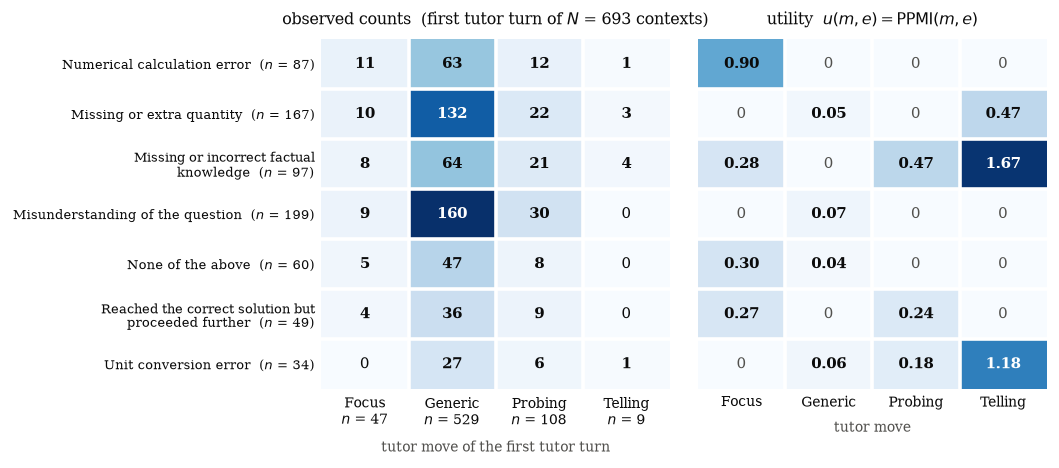

In [9]:
counts = contingency.T.loc[ERRORS, MOVES].values.astype(float)        # rows = error types
row_total = counts.sum(axis=1)                                        # contexts per error type
column_total = counts.sum(axis=0)                                     # first turns per move
utility_values = ppmi.T.loc[ERRORS, MOVES].values

fig, (left, right) = plt.subplots(1, 2, figsize=(7.2, 3.5), gridspec_kw=dict(width_ratios=[1.0, 1.0], wspace=0.08))

# Same single-hue colour scale on both panels; the shown numbers carry the values.
left.imshow(counts, cmap="Blues", vmin=0, vmax=counts.max(), aspect="auto")
right.imshow(utility_values, cmap="Blues", vmin=0, vmax=1.7, aspect="auto")

for row in range(len(ERRORS)):
    for col in range(len(MOVES)):
        count = int(counts[row, col])
        text_color = "white" if count > 0.55 * counts.max() else INK
        left.text(col, row, f"{count}", ha="center", va="center", fontsize=8.4, color=text_color, fontweight="bold" if count > 0 else "normal")

        value = utility_values[row, col]
        text_color = "white" if value > 1.0 else (GREY if value == 0 else INK)
        right.text(col, row, "0" if value == 0 else f"{value:.2f}", ha="center", va="center", fontsize=8.4,
                   color=text_color, fontweight="bold" if value > 0 else "normal")

for panel in (left, right):
    panel.set_xticks(range(len(MOVES)))
    panel.set_yticks(range(len(ERRORS)))
    panel.tick_params(length=0)
    for spine in panel.spines.values():
        spine.set_visible(False)
    for edge in np.arange(0.5, len(MOVES) - 0.5, 1):
        panel.axvline(edge, color="white", linewidth=2)
    for edge in np.arange(0.5, len(ERRORS) - 0.5, 1):
        panel.axhline(edge, color="white", linewidth=2)

left.set_xticklabels([f"{MOVE_LABELS[m]}\n$n$ = {int(total)}" for m, total in zip(MOVES, column_total)], fontsize=7.6, color=INK)
right.set_xticklabels([MOVE_LABELS[m] for m in MOVES], fontsize=7.6, color=INK)
left.set_yticklabels([f"{wrapped(ERROR_LABELS_LONG[e], 32)}  ($n$ = {int(total)})" for e, total in zip(ERRORS, row_total)], fontsize=7.4, color=INK, linespacing=1.15)
right.set_yticklabels([])
left.set_title(f"observed counts  (first tutor turn of $N$ = {N_DIALOGUES} contexts)", fontsize=8.6, color=INK, pad=8)
right.set_title("utility  $u(m, e) = \\mathrm{PPMI}(m, e)$", fontsize=8.6, color=INK, pad=8)
left.set_xlabel("tutor move of the first tutor turn", fontsize=8, color=GREY, labelpad=6)
right.set_xlabel("tutor move", fontsize=8, color=GREY, labelpad=6)

save(fig, "fig_5_6_associations")
plt.show()

# Numbers behind the figure.
table_5_6 = pd.DataFrame({"error_type": np.repeat(ERRORS, len(MOVES)),
                          "move": MOVES * len(ERRORS),
                          "count": counts.flatten().astype(int),
                          "ppmi": utility_values.flatten()})
table_5_6.to_csv(DATA_DIR / "fig_5_6_associations.csv", index=False)

#### 3. `fig_5_7_context_ranking` — two contexts end to end (`fig:context_ranking`, preview Figure 5.8; Section 5.2.2)

All candidates of one context, ranked by the score s(r, e). Top: the score, with the first three pairs
drawn as arcs (rank j with rank n − j + 1); the blue half is chosen, the orange half rejected, the grey
middle candidate is omitted when n is odd. Bottom: the classifier posterior of every candidate, the
input of the score.

Two contexts with opposite utilities: a calculation error (u > 0 only for Focus) and a
factual-knowledge error (u largest for Telling). Both contexts were picked for short, plain responses
at rank 1 and rank n; the texts of that first pair go into the LaTeX table below.


In [10]:
EXAMPLE_CONTEXTS = [609, 150]      # calculation error, missing / incorrect factual knowledge


def ranked_candidates(context_id):
    group = candidates[candidates["context_data_idx"] == context_id]
    return group.sort_values("score", ascending=False, kind="mergesort").reset_index(drop=True)


for context_id in EXAMPLE_CONTEXTS:
    ranked = ranked_candidates(context_id)
    error = ranked["error_category"].iloc[0]
    print(f"context {context_id}: {ERROR_LABELS_LONG[error]}, n = {len(ranked)} candidates, "
          f"{len(ranked) // 2} pairs, top labels {ranked['predicted_pedagogy'].value_counts().to_dict()}")
    print("  problem :", textwrap.shorten(ranked["problem"].iloc[0], 160))
    print("  u(m, e) :", {MOVE_LABELS[m]: round(float(ppmi.loc[m, error]), 3) for m in MOVES})

context 609: Numerical calculation error, n = 69 candidates, 34 pairs, top labels {'focus': 59, 'telling': 10}
  problem : erin counts six trolls hiding by the path in the forest, 6 less than four times that number of trolls hiding under the bridge, and half as many trolls [...]
  u(m, e) : {'Focus': 0.899, 'Generic': 0.0, 'Probing': 0.0, 'Telling': 0.0}
context 150: Missing or incorrect factual knowledge, n = 72 candidates, 36 pairs, top labels {'focus': 60, 'telling': 12}
  problem : james was doing some shopping in his favorite shop and he saw an offer on shoes that give him a second pair of shoes for half off the original price. he [...]
  u(m, e) : {'Focus': 0.282, 'Generic': 0.0, 'Probing': 0.474, 'Telling': 1.667}


saved fig_5_7_context_ranking


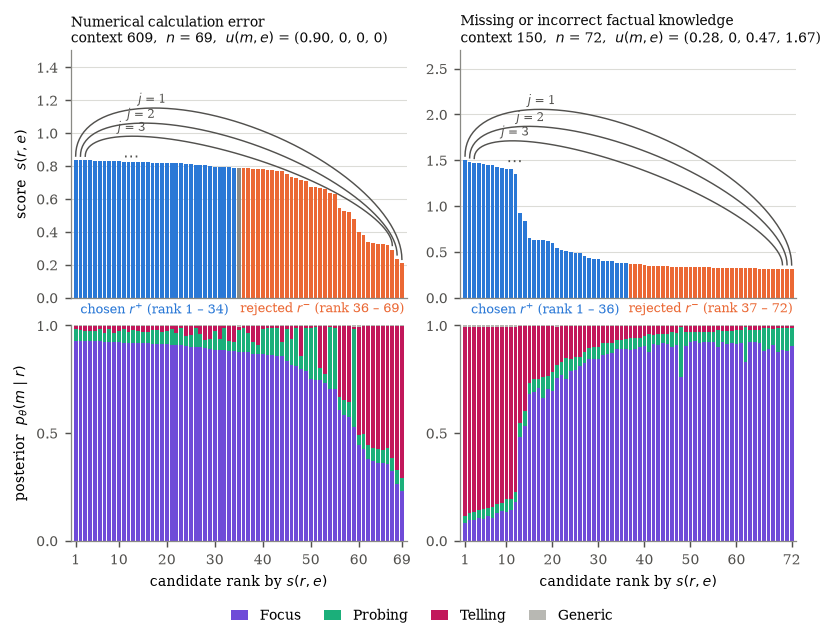

In [11]:
def draw_context(score_panel, posterior_panel, context_id, show_ylabels=True, compact=False, show_xlabel=True):
    # One context: score of every candidate (top) and its posterior (bottom), ranked by the score.
    # compact=True is the small-block variant of the appendix figure (shorter labels, smaller fonts,
    # only the first arc labelled); compact=False is the layout of fig_5_7_context_ranking.
    ranked = ranked_candidates(context_id)
    error = ranked["error_category"].iloc[0]
    n = len(ranked)
    k = n // 2
    rank = np.arange(1, n + 1)
    score = ranked["score"].values
    bar_width = 0.8

    # --- top: the score, coloured by side ----------------------------------------------
    side_color = [CHOSEN_COLOR if r <= k else (REJECTED_COLOR if r > n - k else PALE) for r in rank]
    score_panel.bar(rank, score, width=bar_width, color=side_color, zorder=2)

    # Arcs for the first three pairs (rank j to rank n - j + 1), outer pair on top; dots stand for the rest.
    y_top = score.max()
    t = np.linspace(0, np.pi, 60)
    for j in [1, 2, 3]:
        x1, x2 = j, n - j + 1
        y1, y2 = score[x1 - 1] + y_top * 0.03, score[x2 - 1] + y_top * 0.03
        bulge = y_top * (0.62 - 0.14 * (j - 1))
        arc_x = x1 + (x2 - x1) * (1 - np.cos(t)) / 2
        arc_y = y1 + (y2 - y1) * (1 - np.cos(t)) / 2 + bulge * np.sin(t)
        score_panel.plot(arc_x, arc_y, color=GREY, linewidth=0.8 if not compact else 0.6, zorder=4)
        apex = np.argmax(arc_y)
        if not compact or j == 1:
            score_panel.text(arc_x[apex], arc_y[apex] + y_top * 0.015, f"$j$ = {j}", ha="center", va="bottom",
                             fontsize=6.4 if not compact else 5.6, color=GREY, zorder=5)
    if not compact:
        score_panel.text(arc_x[apex], arc_y[apex] - y_top * 0.16, "$\\cdots$", ha="center", va="center", fontsize=9, color=GREY)

    score_panel.set_xlim(0, n + 1)
    score_panel.set_ylim(0, y_top * 1.80)
    score_panel.set_xticks([])
    score_panel.yaxis.grid(True)
    score_panel.set_axisbelow(True)
    utility_text = ", ".join(utility_label(ppmi.loc[m, error]) for m in MOVES)
    if compact:
        score_panel.set_title(f"{wrapped(ERROR_LABELS_LONG[error], 34)}\ncontext {context_id},  $n$ = {n},  $u$ = ({utility_text})",
                              fontsize=6.6, color=INK, loc="left", pad=3, linespacing=1.25)
        score_panel.tick_params(labelsize=6)
        posterior_panel.tick_params(labelsize=6)
        score_panel.text(k / 2 + 0.5, -0.03, f"chosen 1 – {k}", transform=score_panel.get_xaxis_transform(),
                         ha="center", va="top", fontsize=6, color=CHOSEN_COLOR)
        score_panel.text(n - k / 2 + 0.5, -0.03, f"rejected {n - k + 1} – {n}", transform=score_panel.get_xaxis_transform(),
                         ha="center", va="top", fontsize=6, color=REJECTED_COLOR)
    else:
        score_panel.set_title(f"{ERROR_LABELS_LONG[error]}\ncontext {context_id},  $n$ = {n},  $u(m, e)$ = ({utility_text})",
                              fontsize=7.6, color=INK, loc="left", pad=4, linespacing=1.3)
        # Side labels along the bottom of the score panel.
        score_panel.text(k / 2 + 0.5, -0.02, f"chosen $r^{{+}}$ (rank 1 – {k})", transform=score_panel.get_xaxis_transform(),
                         ha="center", va="top", fontsize=7, color=CHOSEN_COLOR)
        score_panel.text(n - k / 2 + 0.5, -0.02, f"rejected $r^{{-}}$ (rank {n - k + 1} – {n})", transform=score_panel.get_xaxis_transform(),
                         ha="center", va="top", fontsize=7, color=REJECTED_COLOR)
    if show_ylabels:
        score_panel.set_ylabel("score  $s(r, e)$", fontsize=8 if not compact else 6.8)

    # --- bottom: posterior of every candidate, stacked -----------------------------------
    bottom = np.zeros(n)
    for move in ["focus", "probing", "telling", "generic"]:          # Focus at the bottom of each stack
        values = ranked[f"p_{move}"].values
        posterior_panel.bar(rank, values, width=bar_width, bottom=bottom, color=MOVE_COLORS[move],
                            label=MOVE_LABELS[move], zorder=2)
        bottom += values
    posterior_panel.set_xlim(0, n + 1)
    posterior_panel.set_ylim(0, 1)
    posterior_panel.set_yticks([0, 0.5, 1.0])
    step = 10 if not compact else 20
    ticks = [1] + [tick for tick in range(step, n, step) if n - tick >= step // 2] + [n]     # no tick on top of the last one
    posterior_panel.set_xticks(ticks)
    if show_xlabel:
        posterior_panel.set_xlabel("candidate rank by $s(r, e)$" if not compact else "rank by $s(r, e)$", fontsize=8 if not compact else 6.8)
    if show_ylabels:
        posterior_panel.set_ylabel("posterior  $p_{\\theta}(m \\mid r)$", fontsize=8 if not compact else 6.8)


def context_figure(context_ids, name, panel_width=3.6):
    # One column per context, score panel above posterior panel; legend of the moves at the bottom.
    n_columns = len(context_ids)
    fig, axes = plt.subplots(2, n_columns, figsize=(panel_width * n_columns, 4.9), squeeze=False,
                             gridspec_kw=dict(height_ratios=[1.15, 1.0], hspace=0.12, wspace=0.16))
    for col, context_id in enumerate(context_ids):
        draw_context(axes[0, col], axes[1, col], context_id, show_ylabels=(col == 0))
    handles, labels = axes[1, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=4, bbox_to_anchor=(0.5, -0.04), fontsize=8, handlelength=1.2, columnspacing=1.6)
    save(fig, name)
    plt.show()


context_figure(EXAMPLE_CONTEXTS, "fig_5_7_context_ranking")

# Numbers behind the figure: rank, score, posterior, model of every candidate of the two contexts.
table_5_7 = pd.concat([ranked_candidates(c).assign(rank=lambda d: np.arange(1, len(d) + 1)) for c in EXAMPLE_CONTEXTS])
table_5_7 = table_5_7[["context_data_idx", "error_category", "rank", "model", "score", "predicted_pedagogy"] + [f"p_{m}" for m in MOVES] + ["response"]]
table_5_7.to_csv(DATA_DIR / "fig_5_7_context_ranking.csv", index=False)

→ `table_example_pairs.tex` — the second pair (j = 2) of both contexts (`tab:example_pairs`, preview Table 5.2)

Responses are the saved model outputs after the text normalization of stage 1 (lower-cased, whitespace
collapsed). Markdown emphasis in the outputs is rendered as emphasis, math delimiters `\( \)` are left
to LaTeX, everything else is escaped.


In [12]:
def latex_response(text):
    # keep \( ... \) math spans as they are; escape LaTeX specials elsewhere; render markdown emphasis
    pieces = re.split(r"(\\\(.*?\\\))", text)
    escaped = []
    for piece in pieces:
        if piece.startswith("\\("):
            escaped.append(piece)
            continue
        piece = re.sub(r"(?<!\\)\$", r"\\$", piece)          # lone $ -> \$
        for char in ["%", "&", "#", "_"]:
            piece = piece.replace(char, "\\" + char)
        piece = re.sub(r"\*\*(.+?)\*\*", r"\\textbf{\1}", piece)
        piece = re.sub(r"\*(.+?)\*", r"\\textit{\1}", piece)
        escaped.append(piece)
    return "".join(escaped)


def posterior_text(row, prefix="p_"):
    return ", ".join(f"{row[f'{prefix}{m}']:.2f}" for m in MOVES)


# Which pair of each context goes into the table. Pair j joins rank j with rank n - j + 1. The second pair
# is shown for both contexts: there the two responses are of the same two kinds in both contexts, a question
# that sends the student back to one step and a complete calculation (in the first pair of context 609 the
# chosen response is an instruction rather than a question).
EXAMPLE_PAIRS = {609: 2, 150: 2}

lines = [
    "% Table for Section 5.2.2 — one preference pair of each of the two contexts of fig_5_7_context_ranking.",
    "% Generated by result_5_2.ipynb (EXAMPLE_PAIRS gives the pair index per context). Posterior order: Focus, Generic, Probing, Telling.",
    "\\begin{table}[!t]",
    "    \\centering",
    "    \\footnotesize",
    "    \\setlength{\\tabcolsep}{3pt}",
    "    \\renewcommand{\\arraystretch}{1.15}",
    "    \\captionsetup{skip=4pt}",
    "    \\begin{tabularx}{\\linewidth}{@{}l>{\\raggedright\\arraybackslash}Xlr@{}}",
    "        \\toprule",
    "        Side & Tutor response (generation model) & \\mbox{$p_{\\theta}(m \\mid r)$} & \\mbox{$s(r, e)$} \\\\",
]
for context_id in EXAMPLE_CONTEXTS:
    ranked = ranked_candidates(context_id)
    error = ranked["error_category"].iloc[0]
    j = EXAMPLE_PAIRS[context_id]
    n = len(ranked)
    utility_text = ", ".join(utility_label(ppmi.loc[m, error]) for m in MOVES)
    lines.append("        \\midrule")
    lines.append(f"        \\multicolumn{{4}}{{@{{}}l}}{{\\textit{{{ERROR_LABELS_LONG[error]}}} (context {context_id}), "
                 f"$u(m, e)$ = ({utility_text})}} \\\\")
    for side, row in [("Chosen", ranked.iloc[j - 1]), ("Rejected", ranked.iloc[n - j])]:
        lines.append(f"        {side} & {latex_response(row['response'])} ({row['model']}) & "
                     f"\\mbox{{({posterior_text(row)})}} & {row['score']:.2f} \\\\")
lines += [
    "        \\bottomrule",
    "    \\end{tabularx}",
    "    \\caption{Second preference pair ($j = 2$) of the two dialogue contexts in Figure~\\ref{fig:context_ranking}. "
    "The dialogue context (student error type) and the corresponding utility $u(m, e)$ are shown above each pair. "
    "Posterior and utility values are listed in the order \\textit{Focus}, \\textit{Generic}, \\textit{Probing}, \\textit{Telling}; "
    "the score is their inner product.}",
    "    \\label{tab:example_pairs}",
    "\\end{table}",
]
(TEXT_DIR / "table_example_pairs.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")
print("\n".join(lines))

% Table for Section 5.2.2 — one preference pair of each of the two contexts of fig_5_7_context_ranking.
% Generated by result_5_2.ipynb (EXAMPLE_PAIRS gives the pair index per context). Posterior order: Focus, Generic, Probing, Telling.
\begin{table}[!t]
    \centering
    \footnotesize
    \setlength{\tabcolsep}{3pt}
    \renewcommand{\arraystretch}{1.15}
    \captionsetup{skip=4pt}
    \begin{tabularx}{\linewidth}{@{}l>{\raggedright\arraybackslash}Xlr@{}}
        \toprule
        Side & Tutor response (generation model) & \mbox{$p_{\theta}(m \mid r)$} & \mbox{$s(r, e)$} \\
        \midrule
        \multicolumn{4}{@{}l}{\textit{Numerical calculation error} (context 609), $u(m, e)$ = (0.90, 0, 0, 0)} \\
        Chosen & let's look closely at the bridge trolls: the problem says "6 less than four times that number," which means we need to multiply first before subtracting 6. can you try calculating the bridge trolls again using that rule? (gemini-3.5-flash-lite) & \mbox{(0.93, 0.00, 0.05

#### 4. `fig_5_8_posterior_shift` — chosen vs rejected posterior for all four moves (`fig:posterior_shift`, preview Figure A.2; Appendix B, summarized in Section 5.2.2)

One panel per error type, one pair of horizontal bars per move: mean posterior of the chosen responses
(blue) and of the rejected responses (orange) over all pairs of that error type. The axis label carries the
utility u(m, e) of the move; the move with the largest utility is set in bold, so the direction of each
shift can be read against where u > 0. The numbers behind it, including the mean over all candidates
of the error type (`pool_mean`), are in the CSV of this figure; the associated-move-only bar chart of
the simplified draft follows below as `fig_alt_associated_move`.


saved fig_5_8_posterior_shift


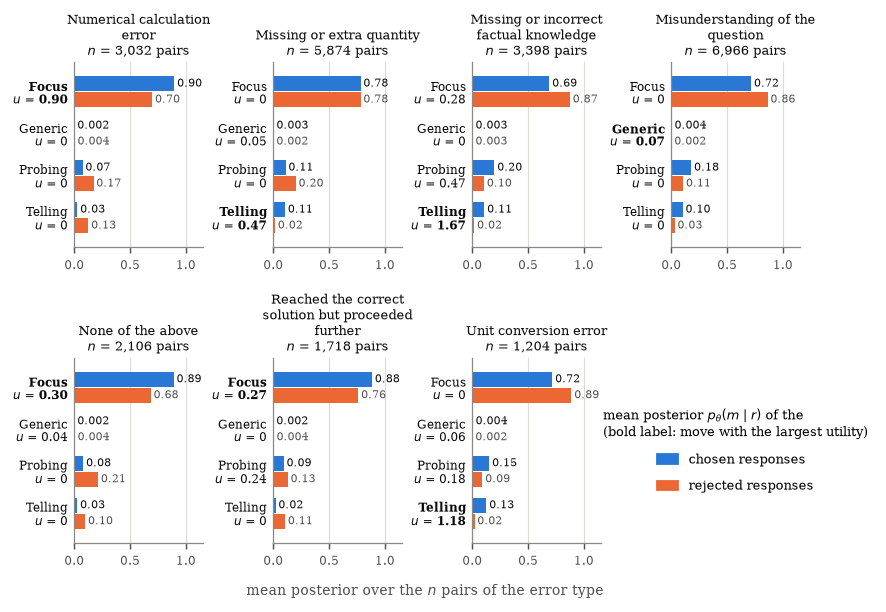

move,focus,generic,probing,telling
error_type,,,,
calculation_error_easily_solved_by_a_calculator,0.198,-0.002,-0.098,-0.098
extra_quantity_or_missing_quantity,0.000,0.001,-0.091,0.090
missing_wrong_factual_knowledge,-0.184,0.001,0.093,0.090
misunderstanding_of_a_question,-0.147,0.002,0.073,0.072
none_of_the_above,0.206,-0.003,-0.132,-0.071
reached_correct_solution_but_proceeded_further,0.123,-0.002,-0.036,-0.085
unit_conversion_error,-0.171,0.002,0.062,0.107


In [13]:
rows = []
for error in ERRORS:
    subset = pairs[pairs["error_category"] == error]
    pool = candidates[candidates["error_category"] == error]          # every candidate of the error type, before ranking
    for move in MOVES:
        rows.append({
            "error_type": error, "move": move, "n_pairs": len(subset), "n_candidates": len(pool),
            "utility": ppmi.loc[move, error],
            "pool_mean": pool[f"p_{move}"].mean(),
            "chosen_mean": subset[f"chosen_p_{move}"].mean(),
            "rejected_mean": subset[f"rejected_p_{move}"].mean(),
        })
posterior_shift = pd.DataFrame(rows)
posterior_shift["difference"] = posterior_shift["chosen_mean"] - posterior_shift["rejected_mean"]
posterior_shift.to_csv(DATA_DIR / "fig_5_8_posterior_shift.csv", index=False)

fig, axes = plt.subplots(2, 4, figsize=(7.2, 4.8), gridspec_kw=dict(hspace=0.6, wspace=0.55))
axes = axes.flatten()
y = np.arange(len(MOVES))[::-1]            # Focus on top
bar_height = 0.36

for panel, error in zip(axes, ERRORS):
    rows = posterior_shift[posterior_shift["error_type"] == error].set_index("move").loc[MOVES]
    chosen_bars = panel.barh(y + bar_height / 2 + 0.01, rows["chosen_mean"], bar_height, color=CHOSEN_COLOR, zorder=2)
    rejected_bars = panel.barh(y - bar_height / 2 - 0.01, rows["rejected_mean"], bar_height, color=REJECTED_COLOR, zorder=2)
    # value at the end of every bar
    for bars, values, color in [(chosen_bars, rows["chosen_mean"], INK), (rejected_bars, rows["rejected_mean"], GREY)]:
        for bar, value in zip(bars, values):
            panel.text(value + 0.025, bar.get_y() + bar.get_height() / 2, value_label(value),
                       ha="left", va="center", fontsize=6.0, color=color)

    panel.set_xlim(0, 1.15)
    panel.set_xticks([0, 0.5, 1.0])
    panel.set_ylim(-0.7, len(MOVES) - 0.3)
    panel.set_yticks(y)
    panel.set_yticklabels([f"{MOVE_LABELS[m]}\n$u$ = {utility_label(rows.loc[m, 'utility'])}" for m in MOVES],
                          fontsize=6.6, color=INK, linespacing=1.1)
    # The move with the largest utility of the error type: bold label.
    panel.get_yticklabels()[MOVES.index(BEST_MOVE[error])].set_fontweight("bold")
    panel.tick_params(axis="y", length=0)
    panel.tick_params(axis="x", labelsize=6.8)
    panel.xaxis.grid(True)
    panel.set_axisbelow(True)
    panel.set_title(f"{ERROR_LABELS_SHORT[error]}\n$n$ = {rows['n_pairs'].iloc[0]:,} pairs", fontsize=7.2, color=INK, pad=4)

# Eighth panel: legend only.
axes[-1].axis("off")
legend_items = [plt.Rectangle((0, 0), 1, 1, color=CHOSEN_COLOR, label="chosen responses"),
                plt.Rectangle((0, 0), 1, 1, color=REJECTED_COLOR, label="rejected responses")]
axes[-1].legend(handles=legend_items, loc="center", fontsize=7.2, labelspacing=1.0, handlelength=1.6,
                title="mean posterior $p_{\\theta}(m \\mid r)$ of the\n(bold label: move with the largest utility)", title_fontsize=7.2)
fig.text(0.5, 0.02, "mean posterior over the $n$ pairs of the error type", ha="center", va="bottom", fontsize=8, color=GREY)

save(fig, "fig_5_8_posterior_shift")
plt.show()

posterior_shift.pivot(index="error_type", columns="move", values="difference").loc[ERRORS, MOVES].round(3)

→ `fig_alt_associated_move` — the associated move only (not in the current draft)

One bar pair per error type: mean posterior that the chosen responses (blue) and the rejected
responses (orange) put on the move with the largest utility of that error type; the black line is the
mean over all candidates of the error type before ranking. Two panels because the associated move is
Focus (probabilities near 0.8) in one family and Telling (near 0.1) in the other. Was Figure 5.9 of the
simplified draft; the figure above shows all four moves instead.


saved fig_alt_associated_move


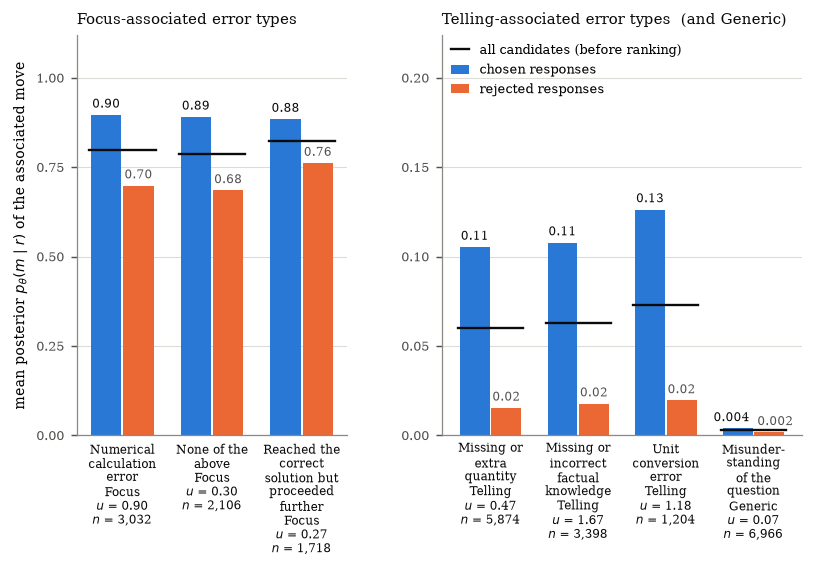

,error_type,move,utility,n_pairs,pool_mean,chosen_mean,rejected_mean,difference
0,calculation_error_easily_solved_by_a_calculator,focus,0.899,3032,0.798,0.896,0.698,0.198
1,none_of_the_above,focus,0.297,2106,0.788,0.891,0.685,0.206
2,reached_correct_solution_but_proceeded_further,focus,0.267,1718,0.823,0.884,0.761,0.123
3,extra_quantity_or_missing_quantity,telling,0.468,5874,0.060,0.105,0.015,0.090
4,missing_wrong_factual_knowledge,telling,1.667,3398,0.063,0.108,0.018,0.090
5,unit_conversion_error,telling,1.179,1204,0.073,0.126,0.019,0.107
6,misunderstanding_of_a_question,generic,0.075,6966,0.003,0.004,0.002,0.002


In [14]:
# Rows of the associated move only, in family order.
associated = (posterior_shift[posterior_shift.apply(lambda r: r["move"] == BEST_MOVE[r["error_type"]], axis=1)]
              .set_index("error_type").loc[FAMILY_ORDER].reset_index())
associated.to_csv(DATA_DIR / "fig_alt_associated_move.csv", index=False)

PANELS = [("Focus-associated error types", FAMILY_ORDER[:3], 1.0, [0, 0.25, 0.5, 0.75, 1.0]),
          ("Telling-associated error types  (and Generic)", FAMILY_ORDER[3:], 0.2, [0, 0.05, 0.1, 0.15, 0.2])]

fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.0), gridspec_kw=dict(width_ratios=[3, 4], wspace=0.3))
bar_width = 0.34
for panel, (title, errors, y_max, y_ticks) in zip(axes, PANELS):
    rows = associated.set_index("error_type").loc[errors]
    x = np.arange(len(errors))
    chosen_bars = panel.bar(x - bar_width / 2 - 0.01, rows["chosen_mean"], bar_width, color=CHOSEN_COLOR, label="chosen responses", zorder=2)
    rejected_bars = panel.bar(x + bar_width / 2 + 0.01, rows["rejected_mean"], bar_width, color=REJECTED_COLOR, label="rejected responses", zorder=2)
    # value above every bar; very small values are nudged apart so that the two labels do not touch
    for bars, values, color, nudge in [(chosen_bars, rows["chosen_mean"], INK, -0.07), (rejected_bars, rows["rejected_mean"], GREY, 0.07)]:
        for bar, value in zip(bars, values):
            shift = nudge if value < 0.01 else 0
            panel.text(bar.get_x() + bar.get_width() / 2 + shift, value + y_max * 0.012, value_label(value),
                       ha="center", va="bottom", fontsize=6.8, color=color)
    # pool mean before ranking: a short black line across the bar pair
    for xi, value in zip(x, rows["pool_mean"]):
        panel.plot([xi - bar_width - 0.03, xi + bar_width + 0.03], [value, value], color=INK, linewidth=1.3, zorder=3,
                   label="all candidates (before ranking)" if xi == 0 else None)
    panel.set_xticks(x)
    panel.set_xticklabels([f"{ERROR_LABELS_NARROW[e]}\n{MOVE_LABELS[BEST_MOVE[e]]}\n$u$ = {utility_label(ppmi.loc[BEST_MOVE[e], e])}\n$n$ = {int(rows.loc[e, 'n_pairs']):,}"
                           for e in errors], fontsize=6.6, color=INK, linespacing=1.2)
    panel.tick_params(axis="x", length=0)
    panel.set_ylim(0, y_max * 1.12)
    panel.set_yticks(y_ticks)
    panel.tick_params(axis="y", labelsize=7)
    panel.yaxis.grid(True)
    panel.set_axisbelow(True)
    panel.set_title(title, fontsize=8.2, color=INK, loc="left", pad=6)
axes[0].set_ylabel("mean posterior $p_{\\theta}(m \\mid r)$ of the associated move", fontsize=8)
# legend in the empty upper part of the right panel
handles, labels = axes[0].get_legend_handles_labels()
axes[1].legend(handles, labels, loc="upper left", fontsize=7.2, handlelength=1.4, labelspacing=0.5, borderaxespad=0.3)

save(fig, "fig_alt_associated_move")
plt.show()

associated[["error_type", "move", "utility", "n_pairs", "pool_mean", "chosen_mean", "rejected_mean", "difference"]].round(3)

#### 5. `fig_5_9_associated_move_share` — pair by pair, associated move only (not in the current draft)

For every pair: does the chosen response put more posterior mass on the move with the largest utility
than the rejected response? One bar per error type = share of its pairs where the answer is yes.
50 % is what a coin flip would give. Was Figure 5.10 of the simplified draft. The same question for all
four moves (the 7 × 4 table with the mean differences, Figure 5.10 of the first detailed draft) is Section 11.
The `pair_difference` table computed here is also used there.


saved fig_5_9_associated_move_share


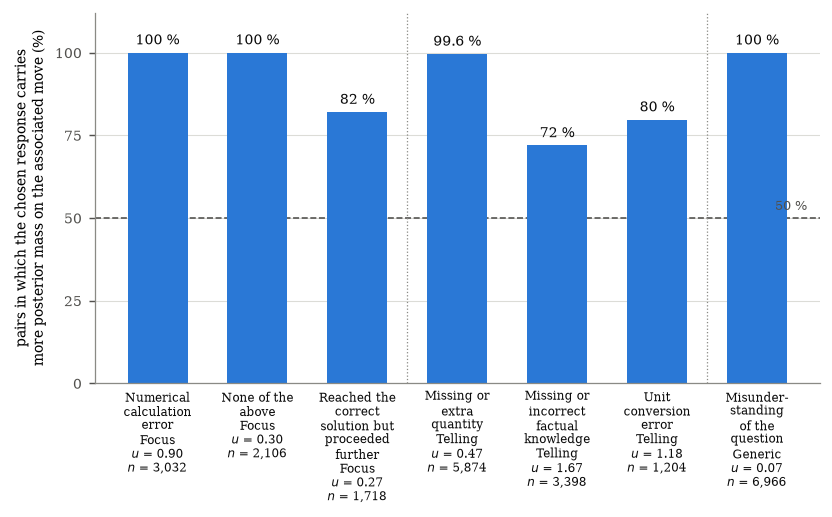

,error_type,move,utility,n_pairs,share_chosen_higher_pct,mean_difference
0,calculation_error_easily_solved_by_a_calculator,focus,0.899,3032,100.000,0.198
1,none_of_the_above,focus,0.297,2106,100.000,0.206
2,reached_correct_solution_but_proceeded_further,focus,0.267,1718,82.014,0.123
3,extra_quantity_or_missing_quantity,telling,0.468,5874,99.591,0.090
4,missing_wrong_factual_knowledge,telling,1.667,3398,71.925,0.090
5,unit_conversion_error,telling,1.179,1204,79.734,0.107
6,misunderstanding_of_a_question,generic,0.075,6966,99.957,0.002


In [15]:
rows = []
for error in ERRORS:
    subset = pairs[pairs["error_category"] == error]
    for move in MOVES:
        difference = subset[f"chosen_p_{move}"] - subset[f"rejected_p_{move}"]
        rows.append({
            "error_type": error, "move": move, "n_pairs": len(subset), "utility": ppmi.loc[move, error],
            "share_chosen_higher_pct": (difference > 0).mean() * 100,
            "mean_difference": difference.mean(), "median_difference": difference.median(),
        })
pair_difference = pd.DataFrame(rows)
pair_difference.to_csv(DATA_DIR / "fig_5_9_pair_difference.csv", index=False)

# The associated move of each error type only, in family order.
associated_share = (pair_difference[pair_difference.apply(lambda r: r["move"] == BEST_MOVE[r["error_type"]], axis=1)]
                    .set_index("error_type").loc[FAMILY_ORDER].reset_index())
associated_share.to_csv(DATA_DIR / "fig_5_9_associated_move_share.csv", index=False)

fig, ax = plt.subplots(figsize=(7.2, 3.7))
x = np.arange(len(FAMILY_ORDER))
bars = ax.bar(x, associated_share["share_chosen_higher_pct"], 0.6, color=CHOSEN_COLOR, zorder=2)
for bar, value in zip(bars, associated_share["share_chosen_higher_pct"]):
    label = f"{value:.1f} %" if 99 < value < 99.95 else f"{value:.0f} %"
    ax.text(bar.get_x() + bar.get_width() / 2, value + 1.5, label, ha="center", va="bottom", fontsize=7.6, color=INK)
# chance level
ax.axhline(50, color=GREY, linestyle="--", linewidth=0.9, zorder=1)
ax.text(len(FAMILY_ORDER) - 0.5, 51.5, "50 %", ha="right", va="bottom", fontsize=7, color=GREY)
# thin separators between the three families
for edge in [2.5, 5.5]:
    ax.axvline(edge, color=PALE, linewidth=0.7, linestyle=":", zorder=1)

ax.set_xticks(x)
ax.set_xticklabels([f"{ERROR_LABELS_NARROW[e]}\n{MOVE_LABELS[BEST_MOVE[e]]}\n$u$ = {utility_label(ppmi.loc[BEST_MOVE[e], e])}\n$n$ = {int(n):,}"
                    for e, n in zip(FAMILY_ORDER, associated_share["n_pairs"])], fontsize=6.6, color=INK, linespacing=1.2)
ax.tick_params(axis="x", length=0)
ax.set_ylim(0, 112)
ax.set_yticks([0, 25, 50, 75, 100])
ax.set_ylabel("pairs in which the chosen response carries\nmore posterior mass on the associated move (%)", fontsize=8)
ax.yaxis.grid(True)
ax.set_axisbelow(True)

save(fig, "fig_5_9_associated_move_share")
plt.show()

associated_share[["error_type", "move", "utility", "n_pairs", "share_chosen_higher_pct", "mean_difference"]].round(3)

#### 6. `fig_5_10_utility_swap` — does the error type change what is chosen? (not in the current draft; the Chapter 6 draft quotes its numbers)

Counterfactual on the saved posteriors: the candidates of every context are re-ranked with the
utility column u(·, e′) of another error type e′, and the pairs are rebuilt with the same rule.
The cell (e, e′) is the share of the chosen responses of the contexts of error type e that stay
chosen under u(·, e′), averaged over those contexts. 100 on the diagonal by definition;
50 is what two unrelated rankings give; values near 0 mean the chosen half becomes the rejected half.


In [16]:
def chosen_set(scores):
    # indices of the top half of a score vector (rank ties broken by original order)
    k = len(scores) // 2
    return set(np.argsort(-scores, kind="mergesort")[:k])


retained = pd.DataFrame(index=ERRORS, columns=ERRORS, dtype=float)
contexts_by_error = {error: [] for error in ERRORS}
for context_id, group in candidates.groupby("context_data_idx"):
    contexts_by_error[group["error_category"].iloc[0]].append(group)

for error in ERRORS:
    for other in ERRORS:
        shares = []
        for group in contexts_by_error[error]:
            posterior = group[[f"p_{m}" for m in MOVES]].values
            true_chosen = chosen_set(group["score"].values)
            other_chosen = chosen_set(posterior @ utility_of(other))
            shares.append(len(true_chosen & other_chosen) / len(true_chosen))
        retained.loc[error, other] = np.mean(shares) * 100
retained.to_csv(DATA_DIR / "fig_5_10_utility_swap.csv")

saved fig_5_10_utility_swap


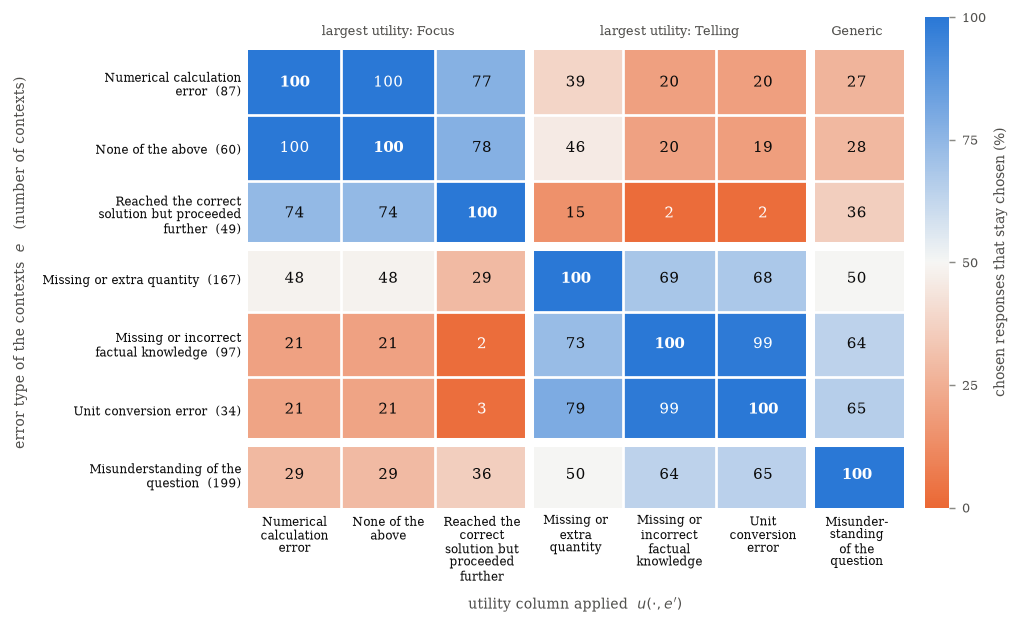

,calculation_error_easily_solved_by_a_calculator,none_of_the_above,reached_correct_solution_but_proceeded_further,extra_quantity_or_missing_quantity,missing_wrong_factual_knowledge,unit_conversion_error,misunderstanding_of_a_question
calculation_error_easily_solved_by_a_calculator,100.0,100.0,77.2,38.5,20.3,19.5,27.0
none_of_the_above,100.0,100.0,77.6,45.9,20.4,19.2,28.5
reached_correct_solution_but_proceeded_further,73.8,73.8,100.0,14.8,1.7,2.3,36.3
extra_quantity_or_missing_quantity,48.4,48.5,29.0,100.0,68.9,68.0,49.7
missing_wrong_factual_knowledge,20.6,20.6,2.0,72.7,100.0,98.7,63.7
unit_conversion_error,21.4,21.4,2.6,79.5,98.7,100.0,65.3
misunderstanding_of_a_question,28.9,28.9,36.2,50.1,63.8,64.7,100.0


In [17]:
matrix = retained.loc[FAMILY_ORDER, FAMILY_ORDER].values


fig, ax = plt.subplots(figsize=(7.0, 4.9))
# Diverging scale centred on 50 %: blue = stays chosen, orange = moves to the rejected half.
swap_cmap = LinearSegmentedColormap.from_list("swap", [REJECTED_COLOR, "#f6f6f4", CHOSEN_COLOR])
image = ax.imshow(matrix, cmap=swap_cmap, norm=TwoSlopeNorm(vmin=0, vcenter=50, vmax=100), aspect="auto")

for row in range(len(FAMILY_ORDER)):
    for col in range(len(FAMILY_ORDER)):
        value = matrix[row, col]
        text_color = "white" if (value >= 85 or value <= 12) else INK        # white only on the saturated cells
        ax.text(col, row, f"{value:.0f}", ha="center", va="center", fontsize=8.4, color=text_color,
                fontweight="bold" if row == col else "normal")

ax.set_xticks(range(len(FAMILY_ORDER)))
ax.set_xticklabels([ERROR_LABELS_NARROW[e] for e in FAMILY_ORDER], fontsize=6.6, color=INK, linespacing=1.15)
ax.set_yticks(range(len(FAMILY_ORDER)))
ax.set_yticklabels([f"{ERROR_LABELS_SHORT[e]}  ({len(contexts_by_error[e])})" for e in FAMILY_ORDER], fontsize=6.8, color=INK, linespacing=1.15)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for edge in np.arange(0.5, len(FAMILY_ORDER) - 0.5, 1):
    ax.axvline(edge, color="white", linewidth=1.5)
    ax.axhline(edge, color="white", linewidth=1.5)
# Thick separators between the three utility families (Focus / Telling / Generic).
for edge in [2.5, 5.5]:
    ax.axvline(edge, color="white", linewidth=5)
    ax.axhline(edge, color="white", linewidth=5)
# Family of each column group, written above the matrix.
for centre, family in [(1, "largest utility: Focus"), (4, "largest utility: Telling"), (6, "Generic")]:
    ax.text(centre, -0.68, family, ha="center", va="bottom", fontsize=7, color=GREY)
ax.set_ylim(len(FAMILY_ORDER) - 0.5, -1.0)

ax.set_xlabel("utility column applied  $u(\\cdot, e')$", fontsize=8, color=GREY, labelpad=8)
ax.set_ylabel("error type of the contexts  $e$   (number of contexts)", fontsize=8, color=GREY, labelpad=8)

colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03, ticks=[0, 25, 50, 75, 100])
colorbar.set_label("chosen responses that stay chosen (%)", fontsize=7.6, color=GREY)
colorbar.outline.set_visible(False)
colorbar.ax.tick_params(labelsize=7, color=PALE, labelcolor=GREY)

save(fig, "fig_5_10_utility_swap")
plt.show()

retained.loc[FAMILY_ORDER, FAMILY_ORDER].round(1)

#### 7. `fig_5_11_margin_by_pair` — score margin by pair index (`fig:margin_by_pair`, preview Figure 5.9; Section 5.2.2)

Pair j of a context pairs rank j with rank n − j + 1, so j = 1 is the widest pair of its context.
The lines are the mean normalized margin Δ / max_m PPMI(m, e) over all contexts of each error type at
each j (raw margins are not comparable across error types because each has its own PPMI scale).
Only the first `J_MIN` pairs are drawn, `J_MIN` = the number of pairs of the shortest context (30), so
that every point rests on all contexts of its error type. The legend names the error types only; the
values at j = 1, 10 and J_MIN are printed below and written to `table_margin_by_pair.tex`.


J_MIN = 30: 20,790 of 24,298 pairs drawn
saved fig_5_11_margin_by_pair


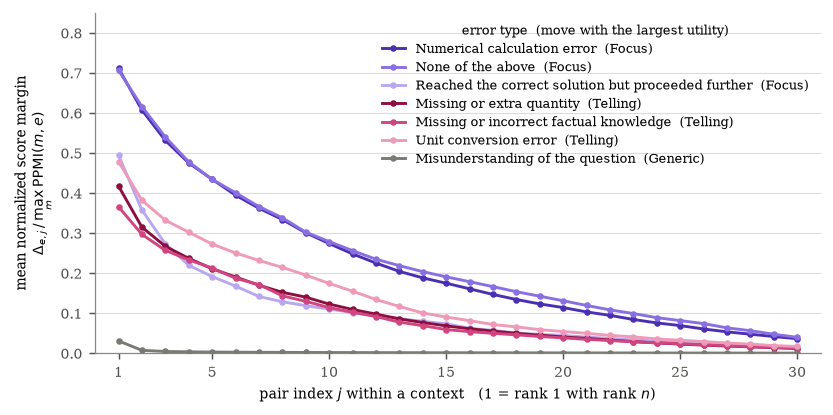

pair_index,1,10,30
error_category,,,
Numerical calculation error,0.712,0.274,0.036
None of the above,0.707,0.279,0.040
Reached the correct solution but proceeded further,0.494,0.110,0.014
Missing or extra quantity,0.417,0.123,0.012
Missing or incorrect factual knowledge,0.366,0.114,0.012
Unit conversion error,0.479,0.174,0.017
Misunderstanding of the question,0.031,0.002,0.000


In [18]:
J_MIN = int(pairs.groupby("context_data_idx")["pair_index"].max().min())        # pairs of the shortest context
margin_by_pair = (pairs[pairs["pair_index"] <= J_MIN]
                  .groupby(["error_category", "pair_index"])["normalized_score_difference"]
                  .agg(mean="mean", std="std", median="median", n_contexts="size")
                  .reset_index())
assert (margin_by_pair.groupby("error_category")["n_contexts"].nunique() == 1).all()   # every point: all contexts
margin_by_pair.to_csv(DATA_DIR / "fig_5_11_margin_by_pair.csv", index=False)
print(f"J_MIN = {J_MIN}: {int(margin_by_pair['n_contexts'].sum()):,} of {len(pairs):,} pairs drawn")

fig, ax = plt.subplots(figsize=(7.2, 3.4))
for error in FAMILY_ORDER:
    rows = margin_by_pair[margin_by_pair["error_category"] == error]
    ax.plot(rows["pair_index"], rows["mean"], color=ERROR_COLORS[error], linewidth=1.6, marker="o", markersize=2.6, zorder=3,
            label=f"{ERROR_LABELS_LONG[error]}  ({MOVE_LABELS[BEST_MOVE[error]]})")
ax.set_xlim(0, J_MIN + 1)
ax.set_xticks([1, 5, 10, 15, 20, 25, J_MIN])
ax.set_ylim(0, 0.85)
ax.set_xlabel("pair index $j$ within a context   (1 = rank 1 with rank $n$)", fontsize=8)
ax.set_ylabel("mean normalized score margin\n$\\Delta_{e,j}\\,/\\,\\max_m \\mathrm{PPMI}(m, e)$", fontsize=8)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.legend(loc="upper right", fontsize=7.2, handlelength=1.8, labelspacing=0.4,
          title="error type  (move with the largest utility)", title_fontsize=7.2)
save(fig, "fig_5_11_margin_by_pair")
plt.show()

# The values quoted in the text, also as a small table (tab:margin_by_pair; optional, next to the figure or in the appendix).
at = margin_by_pair[margin_by_pair["pair_index"].isin([1, 10, J_MIN])].pivot(index="error_category", columns="pair_index", values="mean").loc[FAMILY_ORDER]
contexts = margin_by_pair.groupby("error_category")["n_contexts"].first()
lines = [
    f"% Table for Section 5.2.2 (optional) — mean normalized margin of pair 1, 10 and {J_MIN} over all contexts of each error type.",
    "% Generated by result_5_2.ipynb, Section 7 (numbers: data/fig_5_11_margin_by_pair.csv).",
    "\\begin{table}[!t]",
    "    \\centering",
    "    \\footnotesize",
    "    \\setlength{\\tabcolsep}{5pt}",
    "    \\renewcommand{\\arraystretch}{1.08}",
    "    \\captionsetup{skip=4pt}",
    "    \\begin{tabularx}{\\linewidth}{@{}>{\\raggedright\\arraybackslash}Xlrrrr@{}}",
    "        \\toprule",
    f"        Student error type & Move & Contexts & $j = 1$ & $j = 10$ & $j = {J_MIN}$ \\\\",
    "        \\midrule",
]
for error in FAMILY_ORDER:
    lines.append(f"        {ERROR_LABELS_LONG[error]} & {MOVE_LABELS[BEST_MOVE[error]]} & {int(contexts[error])} & "
                 + " & ".join(f"{at.loc[error, j]:.2f}" for j in [1, 10, J_MIN]) + " \\\\")
lines += [
    "        \\bottomrule",
    "    \\end{tabularx}",
    "    \\caption{Mean normalized score margin $\\Delta_{e,j}/\\max_{m}\\operatorname{PPMI}(m,e)$ of the first, tenth, and " + f"{J_MIN}th pair of a context, "
    "over all contexts of each error type (Figure~\\ref{fig:margin_by_pair}). Move: the move with the largest utility of the error type.}",
    "    \\label{tab:margin_by_pair}",
    "\\end{table}",
]
(TEXT_DIR / "table_margin_by_pair.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")
at.rename(index=ERROR_LABELS_LONG).round(3)

→ `table_margin_by_subset.tex` — median normalized and raw margin of the DPO subsets (`tab:margin_by_subset`)

The DPO subsets of Section 4.6 keep the top ⌊ρ·N_e⌋ pairs of every error type by score margin
(ρ = 0.1, 0.3, 0.5; within an error type the raw and the normalized margin give the same order), pooled
across error types afterwards. Per error type and ρ (ρ = 1: all pairs): the number of retained pairs,
the median normalized margin Δ / max_m PPMI(m, e) and the median raw margin Δ = s(r⁺, e) − s(r⁻, e).
The counts must match Table 4.x of the thesis (2,426 / 7,286 / 12,149); the mean normalized margin of
each subset is printed for the same table.


In [19]:
RATIOS = [0.1, 0.3, 0.5, 1.0]


def top_pairs(subset, rho):
    ordered = subset.sort_values("score_difference", ascending=False, kind="mergesort")
    return ordered.iloc[:int(np.floor(rho * len(ordered)))]


rows, pooled = [], {rho: [] for rho in RATIOS}
for error in ERRORS:
    subset = pairs[pairs["error_category"] == error]
    for rho in RATIOS:
        top = top_pairs(subset, rho)
        pooled[rho].append(top)
        rows.append({"error_type": ERROR_LABELS_LONG[error], "ratio": rho, "n_pairs": len(top),
                     "median_normalized": top["normalized_score_difference"].median(), "mean_normalized": top["normalized_score_difference"].mean(),
                     "median_raw": top["score_difference"].median(), "mean_raw": top["score_difference"].mean(),
                     "min_normalized": top["normalized_score_difference"].min(), "min_raw": top["score_difference"].min()})
for rho in RATIOS:
    top = pd.concat(pooled[rho])
    rows.append({"error_type": "all", "ratio": rho, "n_pairs": len(top),
                 "median_normalized": top["normalized_score_difference"].median(), "mean_normalized": top["normalized_score_difference"].mean(),
                 "median_raw": top["score_difference"].median(), "mean_raw": top["score_difference"].mean(),
                 "min_normalized": top["normalized_score_difference"].min(), "min_raw": top["score_difference"].min()})
margin_by_subset = pd.DataFrame(rows)
margin_by_subset.to_csv(DATA_DIR / "table_margin_by_subset.csv", index=False)
print("subset sizes and mean normalized margin (for Table 4.x of the thesis):")
print(margin_by_subset[margin_by_subset["error_type"] == "all"][["ratio", "n_pairs", "mean_normalized", "median_normalized", "median_raw"]].round(4).to_string(index=False))


def three(value):
    return "$<$0.001" if value < 0.0005 else f"{value:.3f}"


lines = [
    "% Table for Section 5.2.2 or 4.6 — median normalized and raw margin of the pairs retained at each selection ratio, per error type.",
    "% Generated by result_5_2.ipynb, Section 7 (numbers: data/table_margin_by_subset.csv). Row order = tables of Chapter 4.",
    "\\begin{table}[!t]",
    "    \\centering",
    "    \\footnotesize",
    "    \\setlength{\\tabcolsep}{3.5pt}",
    "    \\renewcommand{\\arraystretch}{1.08}",
    "    \\captionsetup{skip=4pt}",
    "    \\begin{tabularx}{\\linewidth}{@{}>{\\raggedright\\arraybackslash}Xrrrrrrrrr@{}}",
    "        \\toprule",
    "        & & \\multicolumn{2}{c}{$\\rho = 0.1$} & \\multicolumn{2}{c}{$\\rho = 0.3$} & \\multicolumn{2}{c}{$\\rho = 0.5$} & \\multicolumn{2}{c}{All pairs} \\\\",
    "        \\cmidrule(lr){3-4} \\cmidrule(lr){5-6} \\cmidrule(lr){7-8} \\cmidrule(lr){9-10}",
    "        Student error type & Pairs & Norm. & Raw & Norm. & Raw & Norm. & Raw & Norm. & Raw \\\\",
    "        \\midrule",
]
for error in ERRORS + ["all"]:
    name = "all" if error == "all" else ERROR_LABELS_LONG[error]
    block = margin_by_subset[margin_by_subset["error_type"] == name].set_index("ratio")
    cells = [f"{int(block.loc[1.0, 'n_pairs']):,}"]
    for rho in RATIOS:
        cells += [three(block.loc[rho, "median_normalized"]), three(block.loc[rho, "median_raw"])]
    if error == "all":
        lines.append("        \\midrule")
        lines.append("        \\textbf{All} & " + " & ".join(f"\\textbf{{{c}}}" for c in cells) + " \\\\")
    else:
        lines.append(f"        {name} & " + " & ".join(cells) + " \\\\")
lines += [
    "        \\bottomrule",
    "    \\end{tabularx}",
    "    \\caption{Median score margin of the preference pairs retained at each selection ratio $\\rho$ of Section~\\ref{sec:pedagogical_alignment_and_evaluation_of_LLM_tutors} "
    "(the top $\\lfloor \\rho N_e \\rfloor$ pairs of every error type by margin; the last column pair is the full dataset). "
    "Norm.: normalized margin $\\Delta_{e,j}/\\max_{m}\\operatorname{PPMI}(m,e)$; Raw: $\\Delta_{e,j} = s(r^{+}, e) - s(r^{-}, e)$. "
    "Pairs: number of pairs of the error type ($N_e$). The row All pools the retained pairs of all error types.}",
    "    \\label{tab:margin_by_subset}",
    "\\end{table}",
]
(TEXT_DIR / "table_margin_by_subset.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")
print("\n".join(lines))
margin_by_subset.pivot(index="error_type", columns="ratio", values="median_normalized").round(3)

subset sizes and mean normalized margin (for Table 4.x of the thesis):
 ratio  n_pairs  mean_normalized  median_normalized  median_raw
   0.1     2426           0.3923             0.4187      0.1999
   0.3     7286           0.2279             0.1478      0.0998
   0.5    12149           0.1612             0.0754      0.0543
   1.0    24298           0.0891             0.0199      0.0118
% Table for Section 5.2.2 or 4.6 — median normalized and raw margin of the pairs retained at each selection ratio, per error type.
% Generated by result_5_2.ipynb, Section 7 (numbers: data/table_margin_by_subset.csv). Row order = tables of Chapter 4.
\begin{table}[!t]
    \centering
    \footnotesize
    \setlength{\tabcolsep}{3.5pt}
    \renewcommand{\arraystretch}{1.08}
    \captionsetup{skip=4pt}
    \begin{tabularx}{\linewidth}{@{}>{\raggedright\arraybackslash}Xrrrrrrrrr@{}}
        \toprule
        & & \multicolumn{2}{c}{$\rho = 0.1$} & \multicolumn{2}{c}{$\rho = 0.3$} & \multicolumn{2}{c}{$\rho =

ratio,0.1,0.3,0.5,1.0
error_type,,,,
Missing or extra quantity,0.452,0.190,0.088,0.025
Missing or incorrect factual knowledge,0.420,0.157,0.084,0.035
Misunderstanding of the question,0.005,0.003,0.002,0.001
None of the above,0.691,0.425,0.296,0.129
Numerical calculation error,0.699,0.418,0.274,0.114
Reached the correct solution but proceeded further,0.460,0.150,0.085,0.038
Unit conversion error,0.525,0.251,0.119,0.047
all,0.419,0.148,0.075,0.020


#### 7b. `fig_A_contexts` — one context per error type in a single figure, same layout as `fig_5_7_context_ranking` (`fig:app_contexts`, preview Figure A.1; Appendix A)

For each error type one context is drawn. `APPENDIX_RULE` picks it:
- `"widest_first_pair"` (used): the context with the largest normalized margin of its first pair, i.e. the
  context in which the scoring separates the two sides most clearly;
- `"median"`: the context whose first-pair normalized margin is the median of the error type (a typical context).

All seven contexts go into one full-page figure: a 3 × 3 grid of blocks (score panel above posterior panel,
the compact variant of `draw_context`), one row per family of the utility table — Focus-associated error
types, Telling-associated error types, and the Generic-only error type — with the legend in the free cells of
the last row. A CSV lists the contexts with the numbers quoted in the text.
`SAVE_SINGLE_CONTEXT_FIGURES = True` additionally writes the seven one-context figures `fig_A_<k>_<error>`
of the earlier draft (not used in the text).


saved fig_A_contexts


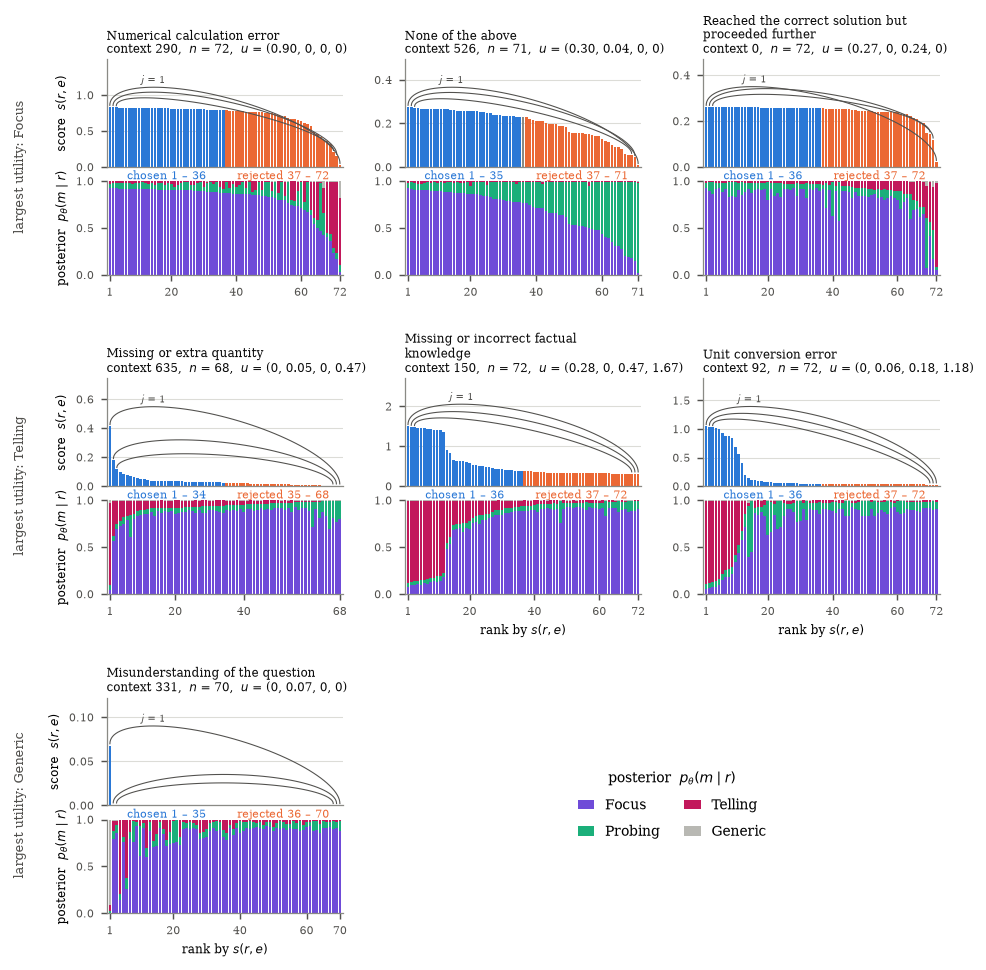

,figure,block,error_type,rule,context_data_idx,median_rule_context,n_candidates,n_pairs,best_move,score_rank_1,...,chosen_mean_p_best,rejected_mean_p_best,n_top_label_focus,n_top_label_probing,n_top_label_telling,chosen_top_label_telling,rejected_top_label_telling,chosen_top_label_probing,rejected_top_label_probing,first_pair_normalized_margin
0,fig_A_contexts,"row 1, column 1",calculation_error_easily_solved_by_a_calculator,widest_first_pair,290,588,72,36,focus,0.833,...,0.905,0.690,66,1,5,0,5,0,1,0.899
1,fig_A_contexts,"row 1, column 2",none_of_the_above,widest_first_pair,526,467,71,35,focus,0.275,...,0.858,0.493,56,15,0,0,0,0,15,0.899
2,fig_A_contexts,"row 1, column 3",reached_correct_solution_but_proceeded_further,widest_first_pair,0,613,72,36,focus,0.261,...,0.888,0.724,68,1,3,0,3,0,1,0.898
3,fig_A_contexts,"row 2, column 1",extra_quantity_or_missing_quantity,widest_first_pair,635,153,68,34,telling,0.413,...,0.126,0.026,67,0,1,1,0,0,0,0.876
4,fig_A_contexts,"row 2, column 2",missing_wrong_factual_knowledge,widest_first_pair,150,139,72,36,telling,1.500,...,0.390,0.027,60,0,12,12,0,0,0,0.713
5,fig_A_contexts,"row 2, column 3",unit_conversion_error,widest_first_pair,92,430,72,36,telling,1.048,...,0.262,0.015,59,2,11,11,0,2,0,0.865
6,fig_A_contexts,"row 3, column 1",misunderstanding_of_a_question,widest_first_pair,331,32,70,35,generic,0.068,...,0.029,0.002,67,0,2,2,0,0,0,0.906


In [20]:
APPENDIX_RULE = "widest_first_pair"


def first_pair_margin(context_id):
    row = pairs[(pairs["context_data_idx"] == context_id) & (pairs["pair_index"] == 1)]
    return float(row["normalized_score_difference"].iloc[0])


def pick_context(error, rule):
    # first pairs (j = 1) of the error type, ordered by their normalized margin
    first_pairs = pairs[(pairs["error_category"] == error) & (pairs["pair_index"] == 1)]
    ordered = first_pairs.sort_values("normalized_score_difference", kind="mergesort").reset_index(drop=True)
    if rule == "median":
        return int(ordered.loc[len(ordered) // 2, "context_data_idx"])
    return int(ordered.loc[len(ordered) - 1, "context_data_idx"])        # widest first pair


APPENDIX_SHORT = {
    "calculation_error_easily_solved_by_a_calculator": "calculation_error",
    "none_of_the_above": "none_of_the_above",
    "reached_correct_solution_but_proceeded_further": "correct_but_continued",
    "extra_quantity_or_missing_quantity": "extra_missing_quantity",
    "missing_wrong_factual_knowledge": "factual_knowledge",
    "unit_conversion_error": "unit_conversion",
    "misunderstanding_of_a_question": "misunderstanding",
}

# Rows of the appendix figure = families of the utility table (row label, error types in column order).
APPENDIX_ROWS = [
    ("largest utility: Focus",   ["calculation_error_easily_solved_by_a_calculator", "none_of_the_above",
                                  "reached_correct_solution_but_proceeded_further"]),
    ("largest utility: Telling", ["extra_quantity_or_missing_quantity", "missing_wrong_factual_knowledge",
                                  "unit_conversion_error"]),
    ("largest utility: Generic", ["misunderstanding_of_a_question"]),
]
SAVE_SINGLE_CONTEXT_FIGURES = False


def appendix_figure(context_of, name):
    # 3 x 3 grid of context blocks; each block = score panel over posterior panel (compact layout).
    fig = plt.figure(figsize=(7.2, 7.3))
    outer = fig.add_gridspec(3, 3, left=0.105, right=0.995, top=0.955, bottom=0.055, hspace=0.48, wspace=0.26)
    legend_source = None
    for row, (family, errors) in enumerate(APPENDIX_ROWS):
        for col, error in enumerate(errors):
            inner = outer[row, col].subgridspec(2, 1, height_ratios=[1.15, 1.0], hspace=0.14)
            score_panel = fig.add_subplot(inner[0])
            posterior_panel = fig.add_subplot(inner[1])
            last_in_column = not any(col < len(APPENDIX_ROWS[r][1]) for r in range(row + 1, len(APPENDIX_ROWS)))
            draw_context(score_panel, posterior_panel, context_of[error], show_ylabels=(col == 0),
                         compact=True, show_xlabel=last_in_column)
            legend_source = legend_source or posterior_panel
        # Family label, rotated, at the left of the row.
        box = outer[row, 0].get_position(fig)
        fig.text(0.012, (box.y0 + box.y1) / 2, family, rotation=90, ha="center", va="center", fontsize=7, color=GREY)
    # Legend of the moves in the free cells of the last row.
    handles, labels = legend_source.get_legend_handles_labels()
    left, right = outer[2, 1].get_position(fig), outer[2, 2].get_position(fig)
    fig.legend(handles, labels, loc="center", bbox_to_anchor=((left.x0 + right.x1) / 2, (left.y0 + left.y1) / 2),
               ncol=2, fontsize=7.5, handlelength=1.2, columnspacing=1.8, labelspacing=0.9, frameon=False,
               title="posterior  $p_{\\theta}(m \\mid r)$", title_fontsize=7.5)
    save(fig, name)
    plt.show()


rows = []
context_of = {}
for k, error in enumerate(FAMILY_ORDER, start=1):
    context_id = pick_context(error, APPENDIX_RULE)
    context_of[error] = context_id
    ranked = ranked_candidates(context_id)
    n = len(ranked)
    half = n // 2
    best = BEST_MOVE[error]
    chosen_half, rejected_half = ranked.iloc[:half], ranked.iloc[-half:]
    row_index = next(r for r, (_, errors) in enumerate(APPENDIX_ROWS) if error in errors)
    rows.append({
        "figure": "fig_A_contexts", "block": f"row {row_index + 1}, column {APPENDIX_ROWS[row_index][1].index(error) + 1}",
        "error_type": error, "rule": APPENDIX_RULE,
        "context_data_idx": context_id, "median_rule_context": pick_context(error, "median"),
        "n_candidates": n, "n_pairs": half, "best_move": best,
        "score_rank_1": ranked["score"].iloc[0], "score_rank_n": ranked["score"].iloc[-1],
        "score_last_chosen": chosen_half["score"].iloc[-1], "score_first_rejected": rejected_half["score"].iloc[0],
        "chosen_mean_p_best": chosen_half[f"p_{best}"].mean(), "rejected_mean_p_best": rejected_half[f"p_{best}"].mean(),
        "n_top_label_focus": int((ranked["predicted_pedagogy"] == "focus").sum()),
        "n_top_label_probing": int((ranked["predicted_pedagogy"] == "probing").sum()),
        "n_top_label_telling": int((ranked["predicted_pedagogy"] == "telling").sum()),
        "chosen_top_label_telling": int((chosen_half["predicted_pedagogy"] == "telling").sum()),
        "rejected_top_label_telling": int((rejected_half["predicted_pedagogy"] == "telling").sum()),
        "chosen_top_label_probing": int((chosen_half["predicted_pedagogy"] == "probing").sum()),
        "rejected_top_label_probing": int((rejected_half["predicted_pedagogy"] == "probing").sum()),
        "first_pair_normalized_margin": first_pair_margin(context_id),
    })
    if SAVE_SINGLE_CONTEXT_FIGURES:
        context_figure([context_id], f"fig_A_{k}_{APPENDIX_SHORT[error]}", panel_width=4.6)
appendix_contexts = pd.DataFrame(rows)
appendix_contexts.to_csv(DATA_DIR / "appendix_contexts.csv", index=False)

appendix_figure(context_of, "fig_A_contexts")
appendix_contexts.round(3)

#### 8. Numbers quoted in the text

Candidate pool composition, per-error-type means, and the shares used in Section 5.2.
Everything printed here is also written to CSV.


In [21]:
print("=== candidate pool (48,839 unique candidates) ===")
pool_top = candidates["predicted_pedagogy"].value_counts(normalize=True).reindex(MOVES, fill_value=0) * 100
print("top label share (%):", pool_top.round(1).to_dict())
print("mean posterior     :", candidates[[f"p_{m}" for m in MOVES]].mean().round(3).to_dict())
pool_by_error = candidates.groupby("error_category")[[f"p_{m}" for m in MOVES]].mean().loc[ERRORS]
print("\nmean posterior of the pool per error type (the input of the scoring, before any ranking):")
print(pool_by_error.round(3).rename(index=ERROR_LABELS_LONG).to_string())
pool_by_error.to_csv(DATA_DIR / "pool_mean_posterior_by_error_type.csv")

print("\n=== per error type: move with the largest utility, chosen vs rejected on that move ===")
rows = []
for error in ERRORS:
    subset = pairs[pairs["error_category"] == error]
    best = BEST_MOVE[error]
    rows.append({
        "error_type": ERROR_LABELS_LONG[error], "best_move": MOVE_LABELS[best], "utility": ppmi.loc[best, error],
        "n_pairs": len(subset),
        "chosen_mean": subset[f"chosen_p_{best}"].mean(), "rejected_mean": subset[f"rejected_p_{best}"].mean(),
        "pairs_chosen_higher_pct": (subset[f"chosen_p_{best}"] > subset[f"rejected_p_{best}"]).mean() * 100,
        "median_margin_first_pair": subset.loc[subset["pair_index"] == 1, "normalized_score_difference"].median(),
    })
best_move_table = pd.DataFrame(rows)
best_move_table.to_csv(DATA_DIR / "best_move_chosen_vs_rejected.csv", index=False)
print(best_move_table.round(3).to_string(index=False))

=== candidate pool (48,839 unique candidates) ===
top label share (%): {'focus': 92.4, 'generic': 0.0, 'probing': 4.5, 'telling': 3.1}
mean posterior     : {'p_focus': 0.791, 'p_generic': 0.003, 'p_probing': 0.141, 'p_telling': 0.065}

mean posterior of the pool per error type (the input of the scoring, before any ranking):
                                                    p_focus  p_generic  p_probing  p_telling
error_category                                                                              
Numerical calculation error                           0.798      0.003      0.123      0.077
Missing or extra quantity                             0.782      0.003      0.156      0.060
Missing or incorrect factual knowledge                0.783      0.003      0.152      0.063
Misunderstanding of the question                      0.789      0.003      0.142      0.066
None of the above                                     0.788      0.003      0.147      0.062
Reached the correct sol

→ `table_candidate_pool.tex` — move distribution of the candidate pool per error type (`tab:candidate_pool`, preview Table A.1; Appendix B, cited in Section 5.2.2)

The input of the scoring before any ranking. Per error type: the number of contexts and candidates, the
mean classifier posterior of all its candidates for each move, the number of candidates per top label
(counts, as in `fig_5_6_associations`), and how many contexts have no Telling-labelled candidate at all.
Row order = tables of Chapter 4. Every context holds about 70 candidates.


In [22]:
rows = []
for error in ERRORS + ["all"]:
    pool = candidates if error == "all" else candidates[candidates["error_category"] == error]
    top_label = pool["predicted_pedagogy"].value_counts().reindex(MOVES, fill_value=0)
    telling_per_context = pool.groupby("context_data_idx")["predicted_pedagogy"].apply(lambda labels: int((labels == "telling").sum()))
    row = {"error_type": "all" if error == "all" else ERROR_LABELS_LONG[error],
           "n_contexts": pool["context_data_idx"].nunique(), "n_candidates": len(pool),
           "candidates_per_context": len(pool) / pool["context_data_idx"].nunique()}
    row.update({f"mean_p_{m}": pool[f"p_{m}"].mean() for m in MOVES})
    row.update({f"top_label_{m}": int(top_label[m]) for m in MOVES})
    row.update({"telling_per_context_mean": telling_per_context.mean(),
                "telling_per_context_max": int(telling_per_context.max()),
                "contexts_without_telling": int((telling_per_context == 0).sum())})
    rows.append(row)
candidate_pool = pd.DataFrame(rows)
candidate_pool.to_csv(DATA_DIR / "table_candidate_pool.csv", index=False)

lines = [
    "% Table for the appendix (cited in Section 5.2.2) — move distribution of the 48,839 candidates (the input of the scoring) per error type.",
    "% Generated by result_5_2.ipynb, Section 8 (numbers: data/table_candidate_pool.csv; the mean posteriors are in that CSV too).",
    "% Row order = tables of Chapter 4.",
    "\\begin{table}[!t]",
    "    \\centering",
    "    \\footnotesize",
    "    \\setlength{\\tabcolsep}{4pt}",
    "    \\renewcommand{\\arraystretch}{1.08}",
    "    \\captionsetup{skip=4pt}",
    "    \\begin{tabularx}{\\linewidth}{@{}>{\\raggedright\\arraybackslash}Xrrrrrrr@{}}",
    "        \\toprule",
    "        & & & \\multicolumn{4}{c}{Candidates per top label} & Contexts without \\\\",
    "        \\cmidrule(lr){4-7}",
    "        Student error type & Contexts & Candidates & Focus & Generic & Probing & Telling & a \\textit{Telling} candidate \\\\",
    "        \\midrule",
]
for _, row in candidate_pool.iterrows():
    cells = ([f"{int(row['n_contexts'])}", f"{int(row['n_candidates']):,}"]
             + [f"{int(row[f'top_label_{m}']):,}" for m in MOVES]
             + [f"{int(row['contexts_without_telling'])}"])
    if row["error_type"] == "all":
        lines.append("        \\midrule")
        lines.append("        \\textbf{All} & " + " & ".join(f"\\textbf{{{c}}}" for c in cells) + " \\\\")
    else:
        lines.append(f"        {row['error_type']} & " + " & ".join(cells) + " \\\\")
lines += [
    "        \\bottomrule",
    "    \\end{tabularx}",
    "    \\caption{Move distribution of the candidate pool by student error type, before any ranking. "
    "For every error type: the number of dialogue contexts and of candidates; the number of candidates whose top label is each move; "
    "and the number of contexts in which no candidate has \\textit{Telling} as its top label. Every context holds about 70 candidates.}",
    "    \\label{tab:candidate_pool}",
    "\\end{table}",
]
(TEXT_DIR / "table_candidate_pool.tex").write_text("\n".join(lines) + "\n", encoding="utf-8")
# print("\n".join(lines))
candidate_pool.round(3)

,error_type,n_contexts,n_candidates,candidates_per_context,mean_p_focus,mean_p_generic,mean_p_probing,mean_p_telling,top_label_focus,top_label_generic,top_label_probing,top_label_telling,telling_per_context_mean,telling_per_context_max,contexts_without_telling
0,Numerical calculation error,87,6104,70.161,0.798,0.003,0.123,0.077,5662,2,199,241,2.770,11,26
1,Missing or extra quantity,167,11808,70.707,0.782,0.003,0.156,0.060,10863,2,627,316,1.892,15,81
2,Missing or incorrect factual knowledge,97,6826,70.371,0.783,0.003,0.152,0.063,6227,4,382,213,2.196,14,49
3,Misunderstanding of the question,199,13997,70.337,0.789,0.003,0.142,0.066,12910,5,644,438,2.201,18,90
4,None of the above,60,4236,70.600,0.788,0.003,0.147,0.062,3920,1,206,109,1.817,10,26
5,Reached the correct solution but proceeded fur...,49,3451,70.429,0.823,0.003,0.112,0.063,3275,2,85,89,1.816,14,20
6,Unit conversion error,34,2417,71.088,0.803,0.003,0.121,0.073,2247,0,78,92,2.706,11,15
7,all,693,48839,70.475,0.791,0.003,0.141,0.065,45104,16,2221,1498,2.162,18,307


#### 9. Material for Chapter 6 (limitations)

Negative or qualifying findings, kept out of Section 5.2:

- 9a. generation model behind the chosen and the rejected responses, per error type (figure; shown in Section 5.2);
- 9b. chi-square test and Cramér's V of the contingency table (numpy only; the Monte-Carlo p-value with
  200,000 resamples is in the stage-1 statistics notebook);
- 9c. the error type *misunderstanding of the question*: score range and margins;
- 9d. pairs whose two responses share the same top label; support behind the Telling utilities;
- 9e. how much of the selection depends on the PPMI magnitudes rather than on the zero pattern of the table.


→ 9a. `fig_5_12_model_composition` — generation model of the chosen and the rejected responses (`fig:model_composition`, preview Figure 5.10; the figure is in Section 5.2, the discussion in the Chapter 6 draft)


saved fig_5_12_model_composition


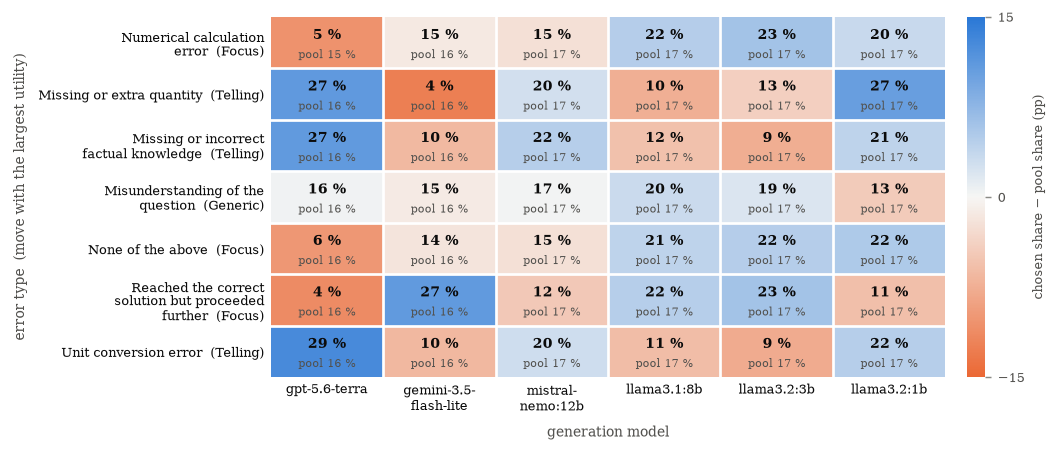

top label share per generation model (%), all candidates:
predicted_pedagogy     focus  generic  probing  telling
model                                                  
gpt-5.6-terra           82.9      0.0      4.7     12.5
gemini-3.5-flash-lite   94.7      0.0      5.3      0.0
mistral-nemo:12b        87.6      0.1      8.2      4.0
llama3.1-8b             93.7      0.0      5.3      1.0
llama3.2:3b             96.7      0.0      3.1      0.2
llama3.2:1b             97.8      0.1      0.8      1.3


In [23]:
MODELS = ["gpt-5.6-terra", "gemini-3.5-flash-lite", "mistral-nemo:12b", "llama3.1-8b", "llama3.2:3b", "llama3.2:1b"]
MODEL_LABELS = {"gpt-5.6-terra": "gpt-5.6-terra", "gemini-3.5-flash-lite": "gemini-3.5-\nflash-lite", "mistral-nemo:12b": "mistral-\nnemo:12b",
                "llama3.1-8b": "llama3.1:8b", "llama3.2:3b": "llama3.2:3b", "llama3.2:1b": "llama3.2:1b"}

rows = []
for error in ERRORS:
    subset = pairs[pairs["error_category"] == error]
    pool = candidates[candidates["error_category"] == error]["model"].value_counts(normalize=True).reindex(MODELS, fill_value=0) * 100
    for side in ["chosen", "rejected"]:
        shares = subset[f"{side}_model"].value_counts(normalize=True).reindex(MODELS, fill_value=0) * 100
        for model in MODELS:
            rows.append({"error_type": error, "side": side, "model": model, "share_pct": shares[model], "pool_share_pct": pool[model]})
model_composition = pd.DataFrame(rows)
model_composition.to_csv(DATA_DIR / "fig_5_12_model_composition.csv", index=False)

# Chosen share minus pool share: > 0 means the model is over-represented on the chosen side.
chosen = model_composition[model_composition["side"] == "chosen"].pivot(index="error_type", columns="model", values="share_pct").loc[ERRORS, MODELS]
pool = model_composition[model_composition["side"] == "chosen"].pivot(index="error_type", columns="model", values="pool_share_pct").loc[ERRORS, MODELS]
excess = chosen - pool

fig, ax = plt.subplots(figsize=(7.2, 3.6))
image = ax.imshow(excess.values, cmap=swap_cmap, norm=TwoSlopeNorm(vmin=-15, vcenter=0, vmax=15), aspect="auto")
for row in range(len(ERRORS)):
    for col in range(len(MODELS)):
        ax.text(col, row - 0.14, f"{chosen.values[row, col]:.0f} %", ha="center", va="center", fontsize=7.6, color=INK, fontweight="bold")
        ax.text(col, row + 0.24, f"pool {pool.values[row, col]:.0f} %", ha="center", va="center", fontsize=6.2, color=GREY)
ax.set_xticks(range(len(MODELS)))
ax.set_xticklabels([MODEL_LABELS[m] for m in MODELS], fontsize=7, color=INK)
ax.set_yticks(range(len(ERRORS)))
ax.set_yticklabels([f"{ERROR_LABELS_SHORT[e]}  ({MOVE_LABELS[BEST_MOVE[e]]})" for e in ERRORS], fontsize=7, color=INK, linespacing=1.15)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for edge in np.arange(0.5, len(MODELS) - 0.5, 1):
    ax.axvline(edge, color="white", linewidth=1.5)
for edge in np.arange(0.5, len(ERRORS) - 0.5, 1):
    ax.axhline(edge, color="white", linewidth=1.5)
ax.set_xlabel("generation model", fontsize=8, color=GREY, labelpad=6)
ax.set_ylabel("error type  (move with the largest utility)", fontsize=8, color=GREY, labelpad=6)
colorbar = fig.colorbar(image, ax=ax, fraction=0.04, pad=0.03, ticks=[-15, 0, 15])
colorbar.set_label("chosen share − pool share (pp)", fontsize=7.4, color=GREY)
colorbar.outline.set_visible(False)
colorbar.ax.tick_params(labelsize=7, color=PALE, labelcolor=GREY)

save(fig, "fig_5_12_model_composition")
plt.show()

# Top label of the pool per model: where the Telling- and Probing-labelled candidates come from.
print("top label share per generation model (%), all candidates:")
print((pd.crosstab(candidates["model"], candidates["predicted_pedagogy"], normalize="index") * 100).reindex(index=MODELS, columns=MOVES).round(1).to_string())

→ 9b. Association test of the contingency table


In [24]:
observed = contingency.values.astype(float)
expected = observed.sum(axis=1, keepdims=True) * observed.sum(axis=0, keepdims=True) / observed.sum()
chi_square = ((observed - expected) ** 2 / expected).sum()
degrees_of_freedom = (observed.shape[0] - 1) * (observed.shape[1] - 1)
cramers_v = np.sqrt(chi_square / (observed.sum() * (min(observed.shape) - 1)))

# Permutation p-value (fixed margins): shuffle the move labels over the 693 dialogues.
rng = np.random.default_rng(42)
move_labels = np.repeat(np.arange(len(MOVES)), observed.sum(axis=1).astype(int))
error_labels = np.repeat(np.arange(len(ERRORS)), observed.sum(axis=0).astype(int))
n_resamples, n_at_least_as_large = 20_000, 0
for _ in range(n_resamples):
    table = np.zeros_like(observed)
    np.add.at(table, (rng.permutation(move_labels), error_labels), 1)
    statistic = np.where(expected > 0, (table - expected) ** 2 / expected, 0).sum()
    n_at_least_as_large += statistic >= chi_square
permutation_p = (n_at_least_as_large + 1) / (n_resamples + 1)

print(f"chi-square = {chi_square:.2f}, df = {degrees_of_freedom}, Cramér's V = {cramers_v:.3f}")
print(f"permutation p (fixed margins, {n_resamples:,} resamples, seed 42) = {permutation_p:.3f}")
print(f"expected counts below 5: {int((expected < 5).sum())} of {expected.size} cells; below 1: {int((expected < 1).sum())}")
print("Telling counts behind its utilities:", {ERROR_LABELS_LONG[e]: int(contingency.loc['telling', e]) for e in ERRORS if ppmi.loc['telling', e] > 0})

chi-square = 25.94, df = 18, Cramér's V = 0.112
permutation p (fixed margins, 20,000 resamples, seed 42) = 0.104
expected counts below 5: 10 of 28 cells; below 1: 3
Telling counts behind its utilities: {'Missing or extra quantity': 3, 'Missing or incorrect factual knowledge': 4, 'Unit conversion error': 1}


→ 9c. Misunderstanding of the question — the only error type whose sole positive utility is Generic


In [25]:
error = "misunderstanding_of_a_question"
pool = candidates[candidates["error_category"] == error]
subset = pairs[pairs["error_category"] == error]
print(f"{ERROR_LABELS_LONG[error]}: {len(pool):,} candidates, {len(subset):,} pairs ({len(subset) / len(pairs):.1%} of all pairs)")
print(f"  utility            : {dict(zip(MOVES, utility_of(error).round(3).tolist()))}")
print(f"  Generic top label in the pool: {(pool['predicted_pedagogy'] == 'generic').mean():.2%}, mean p(Generic) = {pool['p_generic'].mean():.4f}")
print(f"  score range        : {pool['score'].min():.4f} to {pool['score'].max():.4f}  (largest possible = {ppmi[error].max():.3f})")
print(f"  raw margin         : median {subset['score_difference'].median():.4f}, 90th percentile {subset['score_difference'].quantile(0.9):.4f}")
print(f"  pairs with raw margin < 0.001: {(subset['score_difference'] < 0.001).mean():.1%} (all error types: {(pairs['score_difference'] < 0.001).mean():.1%})")
print(f"  pairs with margin exactly 0  : {(subset['score_difference'] == 0).sum()} (all error types: {(pairs['score_difference'] == 0).sum()})")

Misunderstanding of the question: 13,997 candidates, 6,966 pairs (28.7% of all pairs)
  utility            : {'focus': 0.0, 'generic': 0.075, 'probing': 0.0, 'telling': 0.0}
  Generic top label in the pool: 0.04%, mean p(Generic) = 0.0027
  score range        : 0.0001 to 0.0679  (largest possible = 0.075)
  raw margin         : median 0.0001, 90th percentile 0.0002
  pairs with raw margin < 0.001: 98.6% (all error types: 32.6%)
  pairs with margin exactly 0  : 3 (all error types: 3)


→ 9d. Same top label on both sides; support behind the Telling utilities


In [26]:
rows = []
for error in ERRORS:
    subset = pairs[pairs["error_category"] == error]
    same = subset["chosen_label"] == subset["rejected_label"]
    both_focus = same & (subset["chosen_label"] == "focus")
    rows.append({"error_type": ERROR_LABELS_LONG[error], "n_pairs": len(subset),
                 "same_top_label_pct": same.mean() * 100, "both_focus_pct": both_focus.mean() * 100,
                 "u_focus": ppmi.loc["focus", error],
                 "median_norm_margin_same_label": subset.loc[same, "normalized_score_difference"].median()})
same_label = pd.DataFrame(rows)
same_label.to_csv(DATA_DIR / "same_top_label_pairs.csv", index=False)
print(same_label.round(3).to_string(index=False))

                                        error_type  n_pairs  same_top_label_pct  both_focus_pct  u_focus  median_norm_margin_same_label
                       Numerical calculation error     3032              85.422          85.422    0.899                          0.089
                         Missing or extra quantity     5874              85.155          84.712    0.000                          0.023
            Missing or incorrect factual knowledge     3398              82.460          82.460    0.282                          0.026
                  Misunderstanding of the question     6966              85.271          84.841    0.000                          0.001
                                 None of the above     2106              84.995          84.995    0.297                          0.099
Reached the correct solution but proceeded further     1718              89.872          89.814    0.267                          0.033
                             Unit conversion err

→ 9e. PPMI magnitudes vs. zero pattern

The score is a weighted sum, so a positive scaling of a utility column leaves every ranking unchanged.
For an error type whose column has a single positive entry among the moves that the candidates realize
(Generic is realized with a posterior of 0.003 on average), the ranking is the ranking by that one posterior,
and the *value* of the utility plays no role. This cell measures the role of the values for every error
type: the candidates of each context are re-ranked with (a) the column reduced to its sign pattern
(1 where PPMI > 0, else 0) and (b) the column reduced to its largest move alone (one-hot), and the share of
the chosen responses that stay chosen is averaged over the contexts of the error type, as in Section 6.
100 % means the magnitudes are unused for that error type.


In [27]:
rows = []
for error in ERRORS:
    utility = utility_of(error)
    sign_only = (utility > 0).astype(float)
    top_only = np.zeros(len(MOVES)); top_only[int(np.argmax(utility))] = 1.0
    retained_sign, retained_top = [], []
    for group in contexts_by_error[error]:
        posterior = group[[f"p_{m}" for m in MOVES]].values
        true_chosen = chosen_set(group["score"].values)
        retained_sign.append(len(true_chosen & chosen_set(posterior @ sign_only)) / len(true_chosen))
        retained_top.append(len(true_chosen & chosen_set(posterior @ top_only)) / len(true_chosen))
    rows.append({"error_type": ERROR_LABELS_LONG[error], "n_contexts": len(contexts_by_error[error]),
                 "n_pairs": int((pairs["error_category"] == error).sum()),
                 "positive_utilities": int((utility > 0).sum()),
                 "utility": "(" + ", ".join(utility_label(v) for v in utility) + ")",
                 "retained_sign_only_pct": float(np.mean(retained_sign) * 100),
                 "retained_top_move_only_pct": float(np.mean(retained_top) * 100)})
magnitude_check = pd.DataFrame(rows)
magnitude_check.to_csv(DATA_DIR / "utility_magnitude_check.csv", index=False)

unused = magnitude_check[magnitude_check["retained_sign_only_pct"] >= 95]
print(magnitude_check.round(1).to_string(index=False))
print()
print(f"error types in which the sign pattern alone reproduces >= 95 % of the chosen responses: "
      f"{len(unused)} of 7, holding {unused['n_pairs'].sum():,} of {len(pairs):,} pairs "
      f"({unused['n_pairs'].sum() / len(pairs) * 100:.0f} %)")

                                        error_type  n_contexts  n_pairs  positive_utilities               utility  retained_sign_only_pct  retained_top_move_only_pct
                       Numerical calculation error          87     3032                   1       (0.90, 0, 0, 0)                   100.0                       100.0
                         Missing or extra quantity         167     5874                   2    (0, 0.05, 0, 0.47)                    96.4                        99.5
            Missing or incorrect factual knowledge          97     3398                   3 (0.28, 0, 0.47, 1.67)                    35.8                        72.5
                  Misunderstanding of the question         199     6966                   1       (0, 0.07, 0, 0)                   100.0                       100.0
                                 None of the above          60     2106                   2    (0.30, 0.04, 0, 0)                    99.7                       100.0
Reac

#### 10. Not used in the text — top label of the chosen and the rejected responses

Share of chosen and of rejected responses whose top label (arg-max move of the posterior) is
Telling (top) or Probing (bottom), for the n pairs of each error type. The rest of the responses
carry Focus as top label; Generic is the top label of fewer than 0.2 % of the responses on either side.
Shows on which side the few Probing- and Telling-labelled responses of the candidate pool end up.


saved fig_alt_top_label_sides


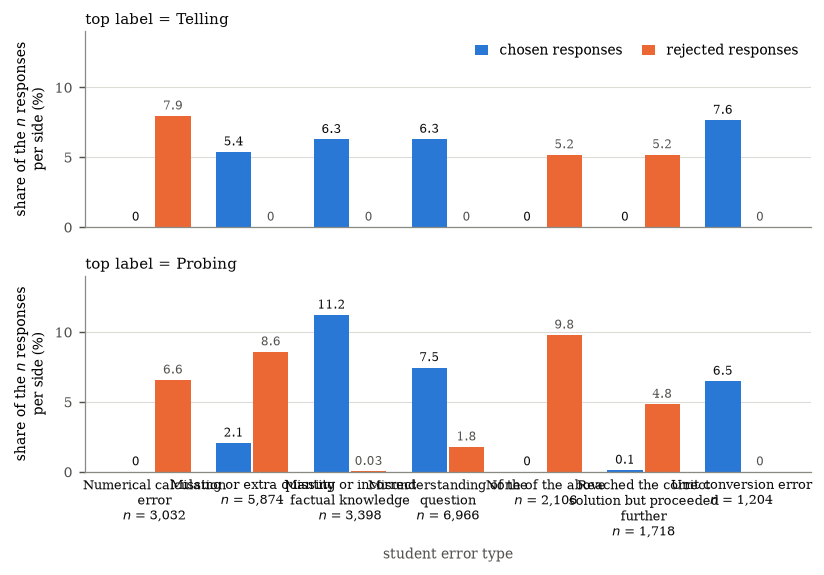

n_pairs  \
error_type                                      side                
calculation_error_easily_solved_by_a_calculator chosen       3032   
                                                rejected     3032   
extra_quantity_or_missing_quantity              chosen       5874   
                                                rejected     5874   
missing_wrong_factual_knowledge                 chosen       3398   
                                                rejected     3398   
misunderstanding_of_a_question                  chosen       6966   
                                                rejected     6966   
none_of_the_above                               chosen       2106   
                                                rejected     2106   
reached_correct_solution_but_proceeded_further  chosen       1718   
                                                rejected     1718   
unit_conversion_error                           chosen       1204   
                                                rejected     1204   

                                                          share_focus_pct  \
error_type                                      side                        
calculation_error_easily_solved_by_a_calculator chosen              100.0   
                                                rejected             85.4   
extra_quantity_or_missing_quantity              chosen               92.5   
                                                rejected             91.4   
missing_wrong_factual_knowledge                 chosen               82.5   
                                                rejected             99.9   
misunderstanding_of_a_question                  chosen               86.2   
                                                rejected             98.2   
none_of_the_above                               chosen              100.0   
                                                rejected             85.0   
reached_correct_solution_but_proceeded_further  chosen               99.9   
                                                rejected             89.9   
unit_conversion_error                           chosen               85.9   
                                                rejected            100.0   

                                                          share_generic_pct  \
error_type                                      side                          
calculation_error_easily_solved_by_a_calculator chosen                  0.0   
                                                rejected                0.1   
extra_quantity_or_missing_quantity              chosen                  0.0   
                                                rejected                0.0   
missing_wrong_factual_knowledge                 chosen                  0.0   
                                                rejected                0.1   
misunderstanding_of_a_question                  chosen                  0.1   
                                                rejected                0.0   
none_of_the_above                               chosen                  0.0   
                                                rejected                0.0   
reached_correct_solution_but_proceeded_further  chosen                  0.0   
                                                rejected                0.1   
unit_conversion_error                           chosen                  0.0   
                                                rejected                0.0   

                                                          share_probing_pct  \
error_type                                      side                          
calculation_error_easily_solved_by_a_calculator chosen                  0.0   
                                                rejected                6.6   
extra_quantity_or_missing_quantity              chosen                  2.1   
                                                rejected    

In [28]:
rows = []
for error in ERRORS:
    subset = pairs[pairs["error_category"] == error]
    for side in ["chosen", "rejected"]:
        shares = subset[f"{side}_label"].value_counts(normalize=True).reindex(MOVES, fill_value=0) * 100
        rows.append({"error_type": error, "side": side, "n_pairs": len(subset), **{f"share_{m}_pct": shares[m] for m in MOVES}})
top_label_sides = pd.DataFrame(rows)
top_label_sides.to_csv(DATA_DIR / "fig_alt_top_label_sides.csv", index=False)

fig, axes = plt.subplots(2, 1, figsize=(7.2, 4.4), sharex=True, gridspec_kw=dict(hspace=0.25))
x = np.arange(len(ERRORS))
bar_width = 0.36

for panel, move in zip(axes, ["telling", "probing"]):
    for side, offset, color in [("chosen", -bar_width / 2 - 0.01, CHOSEN_COLOR), ("rejected", bar_width / 2 + 0.01, REJECTED_COLOR)]:
        rows = top_label_sides[top_label_sides["side"] == side].set_index("error_type").loc[ERRORS]
        share = rows[f"share_{move}_pct"].values
        bars = panel.bar(x + offset, share, bar_width, color=color, label=f"{side} responses", zorder=2)
        # value above every bar: 0 for none, two decimals below 0.1 %, one decimal otherwise
        for bar, value in zip(bars, share):
            label = "0" if value == 0 else (f"{value:.2f}" if value < 0.1 else f"{value:.1f}")
            panel.text(bar.get_x() + bar.get_width() / 2, value + 0.25, label,
                       ha="center", va="bottom", fontsize=6.6, color=INK if side == "chosen" else GREY)
    panel.set_ylim(0, 14)
    panel.set_yticks([0, 5, 10])
    panel.set_ylabel("share of the $n$ responses\nper side (%)", fontsize=7.8)
    panel.yaxis.grid(True)
    panel.set_axisbelow(True)
    panel.tick_params(axis="x", length=0)
    panel.set_title(f"top label = {MOVE_LABELS[move]}", fontsize=8.2, color=INK, loc="left", pad=4)

axes[-1].set_xticks(x)
axes[-1].set_xticklabels([f"{ERROR_LABELS_SHORT[e]}\n$n$ = {n:,}" for e, n in zip(ERRORS, top_label_sides.drop_duplicates('error_type')['n_pairs'])],
                         fontsize=7, color=INK)
axes[-1].set_xlabel("student error type", fontsize=8, color=GREY, labelpad=4)
axes[0].legend(loc="upper right", ncol=2, fontsize=7.6, handlelength=1.0, columnspacing=1.4)

save(fig, "fig_alt_top_label_sides")
plt.show()

top_label_sides.set_index(["error_type", "side"]).round(1)

#### 11. Not used in the text — pair by pair for all four moves (7 × 4 table)

For every pair and every move m: Δ_m = p(m | r⁺) − p(m | r⁻), the full posterior, not the top label.
The cell (e, m) gives the share of the pairs of error type e in which the chosen response carries more
posterior mass on m than the rejected one, with the utility u(m, e) and the mean Δ_m. The framed cell of
each row is the move with the largest utility of that error type. 50 % is what a coin flip would give.


saved fig_alt_pair_difference_all_moves


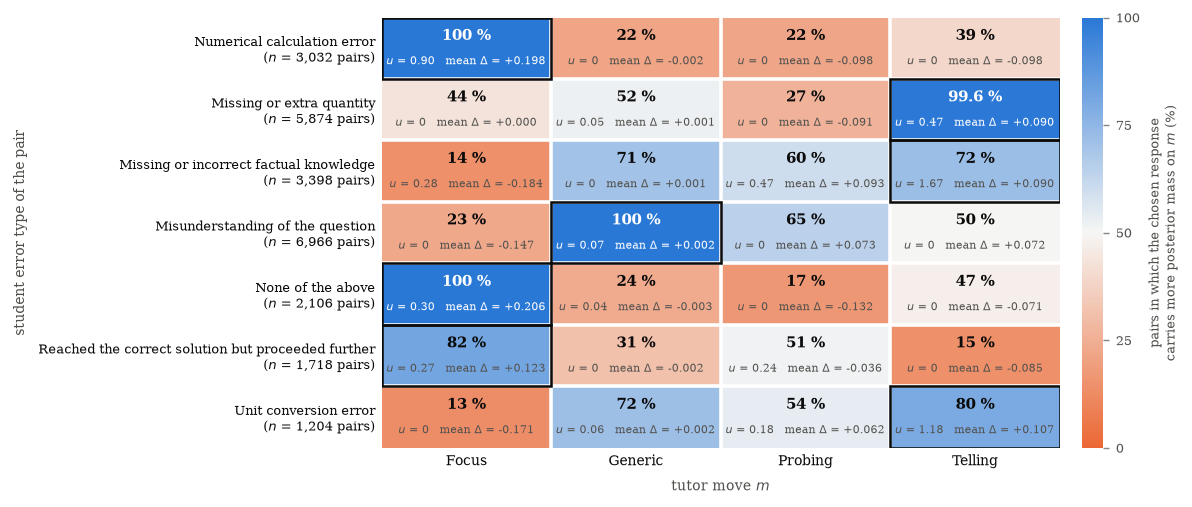

move,focus,generic,probing,telling
error_type,,,,
calculation_error_easily_solved_by_a_calculator,100.0,21.5,22.2,39.3
extra_quantity_or_missing_quantity,43.6,52.2,26.6,99.6
missing_wrong_factual_knowledge,14.4,70.6,59.5,71.9
misunderstanding_of_a_question,22.9,100.0,64.8,49.6
none_of_the_above,100.0,23.9,17.1,47.5
reached_correct_solution_but_proceeded_further,82.0,31.5,51.4,14.7
unit_conversion_error,13.3,71.6,53.8,79.7


In [29]:
# pair_difference is computed in Section 5
share = pair_difference.pivot(index="error_type", columns="move", values="share_chosen_higher_pct").loc[ERRORS, MOVES]
mean_difference = pair_difference.pivot(index="error_type", columns="move", values="mean_difference").loc[ERRORS, MOVES]

fig, ax = plt.subplots(figsize=(7.2, 4.3))
# Diverging scale centred on 50 %: blue = chosen carries more, orange = rejected carries more.
swap_cmap = LinearSegmentedColormap.from_list("swap", [REJECTED_COLOR, "#f6f6f4", CHOSEN_COLOR])
image = ax.imshow(share.values, cmap=swap_cmap, norm=TwoSlopeNorm(vmin=0, vcenter=50, vmax=100), aspect="auto")

for row, error in enumerate(ERRORS):
    for col, move in enumerate(MOVES):
        value = share.loc[error, move]
        text_color = "white" if (value >= 85 or value <= 12) else INK
        sub_color = "white" if (value >= 85 or value <= 12) else GREY
        # one decimal near the ends of the scale, so that 99.6 % does not read as 100 %
        share_label = f"{value:.1f} %" if (0 < value < 0.95 or 99 < value < 99.95) else f"{value:.0f} %"
        ax.text(col, row - 0.2, share_label, ha="center", va="center", fontsize=8.4, color=text_color, fontweight="bold")
        ax.text(col, row + 0.22, f"$u$ = {utility_label(ppmi.loc[move, error])}   mean $\\Delta$ = {mean_difference.loc[error, move]:+.3f}",
                ha="center", va="center", fontsize=6.2, color=sub_color)
    # frame around the move with the largest utility of the row
    best_col = MOVES.index(BEST_MOVE[error])
    ax.add_patch(plt.Rectangle((best_col - 0.5, row - 0.5), 1, 1, fill=False, edgecolor=INK, linewidth=1.4, zorder=5))

ax.set_xticks(range(len(MOVES)))
ax.set_xticklabels([MOVE_LABELS[m] for m in MOVES], fontsize=8, color=INK)
ax.set_yticks(range(len(ERRORS)))
ax.set_yticklabels([f"{ERROR_LABELS_LONG[e]}\n($n$ = {int(share_n):,} pairs)"
                    for e, share_n in zip(ERRORS, pair_difference.drop_duplicates("error_type")["n_pairs"])], fontsize=7.2, color=INK)
ax.tick_params(length=0)
for spine in ax.spines.values():
    spine.set_visible(False)
for edge in np.arange(0.5, len(MOVES) - 0.5, 1):
    ax.axvline(edge, color="white", linewidth=2)
for edge in np.arange(0.5, len(ERRORS) - 0.5, 1):
    ax.axhline(edge, color="white", linewidth=2)
ax.set_xlabel("tutor move $m$", fontsize=8, color=GREY, labelpad=6)
ax.set_ylabel("student error type of the pair", fontsize=8, color=GREY, labelpad=6)

colorbar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.03, ticks=[0, 25, 50, 75, 100])
colorbar.set_label("pairs in which the chosen response\ncarries more posterior mass on $m$ (%)", fontsize=7.4, color=GREY)
colorbar.outline.set_visible(False)
colorbar.ax.tick_params(labelsize=7, color=PALE, labelcolor=GREY)

save(fig, "fig_alt_pair_difference_all_moves")
plt.show()

share.round(1)

#### 12. Text files and the preview PDF

The LaTeX drafts reference the figures by the path they will have inside the thesis folder. This cell checks that every referenced figure was produced above, copies the referenced PDFs next to the standalone preview wrapper, and compiles the wrapper with pdfLaTeX when it is installed (twice, for the cross-references); the result is copied next to the drafts. Without pdfLaTeX, the printed command does the same by hand.

The wrapper uses the thesis class and fonts and resolves the references to Chapters 4–6 with `\newlabel` entries that were read off the current thesis PDF; those numbers are the only thing to update there.


In [30]:
import shutil
import subprocess

# drafts and tables: result_5_2/text/*.tex, figures referenced as figures/<name>.pdf (the path inside the thesis folder)
# preview wrapper: result_5_2/text/preview/preview.tex -> compiled copy result_5_2/text/section_5_2_preview.pdf
TEXT_FILES = ["section_5_2_results.tex", "section_6_2_limitations_draft.tex", "appendix_A_contexts.tex",
              "appendix_B_posterior_comparison.tex", "table_example_pairs.tex", "table_candidate_pool.tex",
              "table_margin_by_pair.tex", "table_margin_by_subset.tex"]
PREVIEW_DIR = TEXT_DIR / "preview"
(PREVIEW_DIR / "figures").mkdir(parents=True, exist_ok=True)

referenced = []
for name in TEXT_FILES:
    text = (TEXT_DIR / name).read_text()
    referenced += re.findall(r"\\includegraphics\[[^\]]*\]\{figures/([^}]+)\}", text)
referenced = sorted(set(referenced))
missing = [f for f in referenced if not (OUT_DIR / f).is_file()]
print(f"figures referenced by the tex files: {len(referenced)}, missing: {missing or 'none'}")
assert not missing, "run the figure sections above first"

for f in referenced:
    shutil.copy2(OUT_DIR / f, PREVIEW_DIR / "figures" / f)
print(f"copied {len(referenced)} PDFs to {PREVIEW_DIR / 'figures'}")

pdflatex = shutil.which("pdflatex")
if pdflatex and (PREVIEW_DIR / "preview.tex").is_file():
    for _ in range(2):
        run = subprocess.run([pdflatex, "-interaction=nonstopmode", "-halt-on-error", "preview.tex"],
                             cwd=PREVIEW_DIR, capture_output=True, text=True)
    if run.returncode == 0:
        shutil.copy2(PREVIEW_DIR / "preview.pdf", TEXT_DIR / "section_5_2_preview.pdf")
        log = (PREVIEW_DIR / "preview.log").read_text(errors="ignore")
        print("compiled", TEXT_DIR / "section_5_2_preview.pdf",
              "| undefined references:", log.count("Reference `"), "| pages:", log.count("[") and re.findall(r"Output written on .*\((\d+) pages", log))
    else:
        print("pdflatex failed; see", PREVIEW_DIR / "preview.log")
        print(run.stdout[-1500:])
else:
    print("pdflatex not found here. To rebuild the preview by hand:")
    print(f"  cd '{PREVIEW_DIR}' && pdflatex preview.tex && pdflatex preview.tex && cp preview.pdf ../section_5_2_preview.pdf")

figures referenced by the tex files: 6, missing: none
copied 6 PDFs to /Users/jay/Desktop/___TUM_Thesis /____Final_Thesis_Repository/result_5_2/text/preview/figures
compiled /Users/jay/Desktop/___TUM_Thesis /____Final_Thesis_Repository/result_5_2/text/section_5_2_preview.pdf | undefined references: 0 | pages: ['16']
